# Paper 3 — *Habit, Not Infrastructure*
### Motorcycle lock-in and micro-enterprise vulnerability on the eve of Metro Line 1

**Truong Tho Living Lab (TTLL), Thu Duc City, Ho Chi Minh City**

This notebook reproduces every number, table and figure in the manuscript, from the raw
survey files and the raw open data. It is deliberately linear: run the cells top to bottom.

| Step | What it does | Approx. runtime |
|---|---|---|
| 1 | Configuration and dependency check | seconds |
| 2 | Load and recode the three TTLL surveys | seconds |
| 3 | **Extract OSM layers from the two Geofabrik `.pbf` snapshots** | ~3 min each, cached |
| 4 | Clip the global GHSL rasters to the study window | ~1 min, cached |
| 5 | Build the master table (accessibility, network walking, POIs, rasters) | ~2 min |
| 6 | Descriptive results, barrier structure — Table 1–3, Figure 1 | seconds |
| 7 | OSM completeness audit — Table 4–5, Figures 2 and 12 | seconds |
| 8 | The two central tests — Table 6–8, Figures 3–5 | seconds |
| 9 | Logistic regression and interpretable ML — Table 9–11, Figures 6–7 | ~1 min |
| 10 | Micro-enterprises — Table 12–14, Figure 9 | seconds |
| 11 | Policy gap and PCI benchmark — Table 15–16, Figures 8 and 11 | seconds |
| 12 | Built-environment change along the corridor — Table 17–18, Figure 10 | ~1 min |

**Memory note.** Step 3 holds the coordinates of every OSM node inside the study window in
a Python dict (~700 000 entries, roughly 300 MB). The two `.pbf` files are read twice each,
never fully loaded. On a machine with less than 4 GB of free RAM, or with less than 1 GB of
free disk, run this notebook on Google Colab instead — everything except the GHSL clipping
step (which needs the two 6.4 GB `GHS_POP` files) works there unchanged, and step 4 will fall
back to the pre-clipped rasters in `DataPaper3/clip/` if the full-size files are absent.

## 1 · Configuration

In [1]:
import os, sys, subprocess

def ensure(pkgs):
    """Install anything missing (safe to re-run; a no-op when everything is present)."""
    missing = []
    for imp, pip in pkgs:
        try:
            __import__(imp)
        except ImportError:
            missing.append(pip)
    if missing:
        print("installing:", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure([("pandas", "pandas"), ("numpy", "numpy"), ("scipy", "scipy"),
        ("matplotlib", "matplotlib"), ("statsmodels", "statsmodels"),
        ("sklearn", "scikit-learn"), ("openpyxl", "openpyxl"), ("xlrd", "xlrd"),
        ("osmium", "osmium"), ("pyproj", "pyproj"), ("networkx", "networkx"),
        ("rasterio", "rasterio")])

In [2]:
from pathlib import Path
import json, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
np.random.seed(42)

# --- where things live -------------------------------------------------------
# BASE is the Paper3 folder (the one that contains DataPaper3/).
BASE = Path(os.environ.get("P3_BASE", ".")).resolve()
if not (BASE / "DataPaper3").exists():
    for cand in [Path.cwd(), Path.cwd() / "Paper3", Path("/content/Paper3")]:
        if (cand / "DataPaper3").exists():
            BASE = cand.resolve(); break

DATA   = BASE / "DataPaper3"          # open data downloaded for this paper
DSET   = DATA / "dataset"             # OSM .pbf, PCI, GHSL zips
CLIP   = DATA / "clip"                # small GHSL clips produced in step 4
DERIV  = BASE / "Derived"             # intermediate products written by this notebook
FIG    = BASE / "Figures"
TAB    = BASE / "Tables"
for d in (CLIP, DERIV, FIG, TAB, DERIV / "osm"):
    d.mkdir(parents=True, exist_ok=True)

# TTLL survey files: normally one level up, in 17_TruongTho/Data
SURVEY = None
for cand in [BASE.parent / "Data", BASE / "Data", DATA / "Data"]:
    if (cand / "QData_Citizens.xlsx").exists():
        SURVEY = cand; break
assert SURVEY is not None, "QData_Citizens.xlsx not found - set SURVEY manually"

print("BASE   :", BASE)
print("SURVEY :", SURVEY)
print("figures ->", FIG, "\ntables  ->", TAB)

# --- study window ------------------------------------------------------------
# Wide enough to hold the whole Metro Line 1 alignment (Ben Thanh -> Suoi Tien)
# plus the seven Truong Tho study wards.
W, S, E, N = 106.66, 10.74, 106.85, 10.92
UTM = "EPSG:32648"          # UTM zone 48N - metric CRS for all distance work

BASE   : D:\Support\Paper2026\17_TruongTho\Paper3
SURVEY : D:\Support\Paper2026\17_TruongTho\Data
figures -> D:\Support\Paper2026\17_TruongTho\Paper3\Figures 
tables  -> D:\Support\Paper2026\17_TruongTho\Paper3\Tables


## 2 · Surveys: load and recode

Three TTLL instruments are used: residents (*n* = 460), micro-enterprises (*n* = 80) and
local officials (*n* = 23). Four recoding decisions matter and are made explicit here.

1. **`Q1.10` (main mode) is multi-select**, stored as a semicolon-terminated string. It is
   parsed by substring, not by exact match.
2. **`Q2.8` (reason for not using public transport) contains a non-reason.** The option
   *"Có sử dụng phương tiện công cộng"* ("I do use public transport", *n* = 14) sits inside a
   list of reasons for *not* using it. This is a questionnaire-design fault. Both denominators
   are reported: 460 (all respondents, the figure used in earlier TTLL outputs) and 446
   (non-users only, the defensible denominator).
3. **`GioiTinh` is `"Nam"`/`"Nữ"`** — both begin with *n*, so sex must be recoded by exact
   equality. A `startswith` test silently makes the variable degenerate.
4. **SME `Q4.2` (profit) has four different "declined to answer" strings**; all are treated
   as missing rather than as a level of the ordinal scale.

In [3]:
cit = pd.read_excel(SURVEY / "QData_Citizens.xlsx")
sme = pd.read_excel(SURVEY / "QData_SMEs.xlsx")
aut = pd.read_excel(SURVEY / "QData_Authorities.xlsx")
cit["rid"] = ["C%03d" % i for i in range(1, len(cit) + 1)]
sme["rid"] = ["S%03d" % i for i in range(1, len(sme) + 1)]

BARRIER = {
    "Thói quen sử dụng xe máy để di chuyển": ("Motorcycle habit", "Behavioural"),
    "Không cảm thấy thoải mái khi phải đi bộ đến các trạm": ("Walking discomfort", "Experiential"),
    "Số lượng điểm dừng và tần suất các chuyến chưa đủ": ("Stop density / frequency", "Infrastructure"),
    "Thiếu cơ sở hạ tầng giữ xe cá nhân tại các trạm giao thông công cộng":
        ("No parking at stops", "Infrastructure"),
    "Chất lượng xe buýt và thái độ phục vụ chưa tốt": ("Bus quality / staff", "Service"),
    "Có sử dụng phương tiện công cộng": ("Uses public transport", "Not a barrier"),
}
cit["reason_en"]    = cit["Q2.8_LyDo_KSD_PTCC"].map(lambda v: BARRIER.get(v, ("Other", "Other"))[0])
cit["reason_class"] = cit["Q2.8_LyDo_KSD_PTCC"].map(lambda v: BARRIER.get(v, ("Other", "Other"))[1])

INC = {"<5 triệu/tháng": 1, "5-15 triệu/tháng": 2, "15-25 triệu/tháng": 3,
       "25-35 Triệu/tháng": 4, ">35 Triệu/tháng": 5}
EDU = {"Tiểu học": 1, "Trung học cơ sở": 2, "Trung học phổ thông": 3, "Trung cấp nghề": 4,
       "Cao Đẳng": 5, "Đại học": 6, "Thạc sĩ": 7}
COM = {"<10 phút": 1, "10-20 phút": 2, "20-30 phút": 3, ">30 phút": 4}
cit["income"]        = cit["Q1.9_ThuNhapHoGD"].map(INC)
cit["education"]     = cit["Q1.8_TrinhDo"].map(EDU)
cit["commute_min"]   = cit["Q2.7_TG_DiChuyenDiLam"].map(COM)
cit["female"]        = (cit["GioiTinh"].astype(str).str.strip() == "Nữ").astype(int)
cit["age"]           = 2023 - cit["NamSinh"]
cit["self_employed"] = (cit["Q1.7_NgheNghiep"] == "Kinh doanh").astype(int)
cit["moto"]          = cit["Q1.10_PTDiChuyen"].astype(str).str.contains("Xe máy cá nhân").astype(int)

# integrity assertions - these are the four traps listed above
assert cit["female"].sum() == 250, "sex recode failed (check Nam/Nữ exact match)"
assert cit["moto"].sum() == 384,   "mode recode failed (Q1.10 is multi-select)"
assert cit["education"].notna().all(), "unmapped education label"
assert (cit["reason_en"] == "Other").sum() == 0, "unmapped Q2.8 option"

def geo_ok(df):
    return df.Long.between(106.5, 107.1) & df.Lat.between(10.6, 11.1)
cit["geo_ok"], sme["geo_ok"] = geo_ok(cit), geo_ok(sme)
print("residents with usable coordinates:", int(cit.geo_ok.sum()), "/", len(cit),
      "  (1 record has a transposed longitude and is excluded from spatial work only)")
print("micro-enterprises with usable coordinates:", int(sme.geo_ok.sum()), "/", len(sme))
cit["Q1.10_PTDiChuyen"].value_counts()

residents with usable coordinates: 459 / 460   (1 record has a transposed longitude and is excluded from spatial work only)
micro-enterprises with usable coordinates: 80 / 80


Q1.10_PTDiChuyen
Xe máy cá nhân;            384
Khác                        21
Xe điện 2 bánh cá nhân;     15
Ô tô cá nhân;               13
Xe đạp;                     12
Xe buýt                      8
Grab/ taxi                   5
Ô tô điện cá nhân;           2
Name: count, dtype: int64

## 3 · Extract OSM layers from the two Geofabrik snapshots

`vietnam-230101.osm.pbf` matches the survey period; `vietnam-260101.osm.pbf` is the current
state, one year after Metro Line 1 opened commercially on 22 December 2024.

The extraction is a **two-pass, memory-light** design. Pass 1 walks every node and keeps the
coordinates only of nodes inside the study window; pass 2 walks the ways and rebuilds their
geometry from that cache. `osmium.SimpleHandler` runs *every* callback it defines on *every*
pass, so the two passes are two separate handler classes — a single class with both `node()`
and `way()` applied twice double-counts silently.

In [4]:
import osmium


# bbox and priority tag sets used by both passes
PT_NODE = ("highway", "bus_stop")

In [5]:
POI_AMEN = {"restaurant", "cafe", "fast_food", "marketplace", "pharmacy", "bank",
            "fuel", "school", "clinic", "hospital", "atm", "bar", "food_court",
            "convenience", "car_repair", "motorcycle_parking", "parking"}

ROAD_OK = {"motorway", "trunk", "primary", "secondary", "tertiary", "unclassified",
           "residential", "living_street", "service", "motorway_link", "trunk_link",
           "primary_link", "secondary_link", "tertiary_link", "road"}
WALK_OK = {"footway", "path", "pedestrian", "steps", "track", "cycleway",
           "residential", "living_street", "service", "unclassified", "tertiary",
           "secondary", "primary", "road"}


class P1(osmium.SimpleHandler):
    def __init__(self):
        super().__init__()
        self.coords = {}
        self.transit = []   # bus stops / platforms / stop positions
        self.rail = []      # railway stations, subway entrances
        self.poi = []
        self.n = 0

    def node(self, n):
        self.n += 1
        lon, lat = n.location.lon, n.location.lat
        if not (W <= lon <= E and S <= lat <= N):
            return
        self.coords[n.id] = (lon, lat)
        t = dict(n.tags)
        if not t:
            return
        hw = t.get("highway"); pt = t.get("public_transport")
        rw = t.get("railway"); am = t.get("amenity"); sh = t.get("shop")
        if hw == "bus_stop" or pt in ("platform", "stop_position", "station") or am == "bus_station":
            self.transit.append({"id": n.id, "lon": lon, "lat": lat,
                                 "name": t.get("name"), "highway": hw,
                                 "public_transport": pt, "amenity": am,
                                 "railway": rw, "route": t.get("route"),
                                 "bus": t.get("bus"), "train": t.get("train"),
                                 "subway": t.get("subway"), "station": t.get("station")})
        if rw in ("station", "halt", "subway_entrance", "tram_stop", "stop"):
            self.rail.append({"id": n.id, "lon": lon, "lat": lat, "name": t.get("name"),
                              "railway": rw, "station": t.get("station"),
                              "subway": t.get("subway"), "network": t.get("network"),
                              "operator": t.get("operator"), "name_en": t.get("name:en")})
        if sh or (am in POI_AMEN):
            self.poi.append({"id": n.id, "lon": lon, "lat": lat,
                             "shop": sh, "amenity": am, "name": t.get("name")})


class P2(osmium.SimpleHandler):
    def __init__(self, coords):
        super().__init__()
        self.coords = coords
        self.roads = []
        self.rail_ways = []
        self.poi_ways = []
        self.transit_ways = []

    def _geom(self, w):
        pts = []
        for nd in w.nodes:
            c = self.coords.get(nd.ref)
            if c is None:
                return None
            pts.append(c)
        return pts if len(pts) >= 2 else None

    def way(self, w):
        t = dict(w.tags)
        if not t:
            return
        hw = t.get("highway"); rw = t.get("railway")
        am = t.get("amenity"); sh = t.get("shop"); pt = t.get("public_transport")
        want = (hw in ROAD_OK or hw in WALK_OK) or rw or sh or (am in POI_AMEN) or pt
        if not want:
            return
        g = self._geom(w)
        if g is None:
            return
        rec = {"id": w.id, "name": t.get("name"), "geom": g}
        if hw:
            self.roads.append({**rec, "highway": hw,
                               "is_road": hw in ROAD_OK, "is_walk": hw in WALK_OK,
                               "foot": t.get("foot"), "sidewalk": t.get("sidewalk"),
                               "oneway": t.get("oneway"), "maxspeed": t.get("maxspeed")})
        if rw:
            self.rail_ways.append({**rec, "railway": rw, "station": t.get("station"),
                                   "subway": t.get("subway"), "network": t.get("network"),
                                   "name_en": t.get("name:en")})
        if pt in ("platform", "station", "stop_area"):
            self.transit_ways.append({**rec, "public_transport": pt,
                                      "highway": hw, "railway": rw})
        if sh or (am in POI_AMEN):
            self.poi_ways.append({**rec, "shop": sh, "amenity": am})

In [6]:
def extract_osm(pbf_path, tag, out_dir):
    """Run both passes over one .pbf and cache the result as JSON."""
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    done = out_dir / f"roads_{tag}.json"
    if done.exists():
        print(f"[{tag}] cache hit - skipping extraction")
        return
    print(f"[{tag}] pass 1 (nodes) ...", flush=True)
    h1 = P1(); h1.apply_file(str(pbf_path))
    print(f"[{tag}]   nodes seen={h1.n:,} cached={len(h1.coords):,} "
          f"transit={len(h1.transit)} rail={len(h1.rail)} poi={len(h1.poi)}", flush=True)
    print(f"[{tag}] pass 2 (ways) ...", flush=True)
    h2 = P2(h1.coords); h2.apply_file(str(pbf_path))
    print(f"[{tag}]   roads={len(h2.roads)} rail_ways={len(h2.rail_ways)} "
          f"poi_ways={len(h2.poi_ways)}", flush=True)
    for name, obj in [("transit_nodes", h1.transit), ("rail_nodes", h1.rail),
                      ("poi_nodes", h1.poi), ("roads", h2.roads),
                      ("rail_ways", h2.rail_ways), ("poi_ways", h2.poi_ways),
                      ("transit_ways", h2.transit_ways)]:
        json.dump(obj, open(out_dir / f"{name}_{tag}.json", "w"))
    del h1, h2

OSMDIR = DERIV / "osm"
extract_osm(DSET / "vietnam-230101.osm.pbf", "osm2023", OSMDIR)
extract_osm(DSET / "vietnam-260101.osm.pbf", "osm2026", OSMDIR)

[osm2023] cache hit - skipping extraction
[osm2026] cache hit - skipping extraction


## 4 · Clip the global GHSL rasters to the study window

`GHS_POP` (100 m population) and `GHS_BUILT_S` (100 m built-up surface) ship as global
Mollweide mosaics of 6.4 GB and 2 GB respectively. Reading them through a *window* costs
seconds and a few hundred kilobytes; extracting the BUILT-S zips is unnecessary because GDAL
reads them in place through `/vsizip/`. The clips are written once and reused.

In [7]:
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

def clip_to_window(src_path, out_path):
    out_path = Path(out_path)
    if out_path.exists():
        return out_path
    with rasterio.open(str(src_path)) as src:
        b   = transform_bounds("EPSG:4326", src.crs, W, S, E, N, densify_pts=51)
        win = from_bounds(*b, transform=src.transform)
        a   = src.read(1, window=win)
        prof = src.profile.copy()
        prof.update(height=a.shape[0], width=a.shape[1],
                    transform=src.window_transform(win), compress="lzw", BIGTIFF="NO")
        with rasterio.open(str(out_path), "w", **prof) as d:
            d.write(a, 1)
    print("clipped", out_path.name, a.shape, "sum =", float(a.sum()))
    return out_path

for yr in ("2020", "2025"):
    full = DATA / f"GHS_POP_E{yr}_GLOBE_R2023A_54009_100_V1_0.tif"
    tgt  = CLIP / f"GHSPOP_{yr}_TTLL.tif"
    if full.exists():
        clip_to_window(full, tgt)
    stem = f"GHS_BUILT_S_E{yr}_GLOBE_R2023A_54009_100_V1_0"
    zf   = DSET / "GHSL BUILT-S" / f"{stem}.zip"
    tgt2 = CLIP / f"GHSBUILTS_{yr}_TTLL.tif"
    if zf.exists():
        clip_to_window(f"/vsizip/{zf}/{stem}.tif", tgt2)

for f in sorted(CLIP.glob("*.tif")):
    print(" ", f.name, f"{f.stat().st_size/1024:.0f} kB")
assert len(list(CLIP.glob("*.tif"))) == 4, "GHSL clips missing - see the memory note at the top"

  GHSBUILTS_2020_TTLL.tif 99 kB
  GHSBUILTS_2025_TTLL.tif 101 kB
  GHSPOP_2020_TTLL.tif 214 kB
  GHSPOP_2025_TTLL.tif 218 kB


## 5 · Build the master table

Twelve derived variables per respondent. The two that carry the argument are
`net_dist_bus_m` (walking distance **along the pedestrian network**, not as the crow flies)
and `detour_ratio` (network ÷ straight-line), which separates *far* from *awkward to reach* —
two dwellings 300 m from the same stop can have very different walks if one must go around
several dead ends.

Network distance is computed once per snapshot with a **single multi-source Dijkstra**: a
virtual source node is joined to every stop's nearest graph node, so one pass yields the
distance from every graph node to its nearest stop.

In [8]:
from pyproj import Transformer
from scipy.spatial import cKDTree
import networkx as nx

TR = Transformer.from_crs("EPSG:4326", "EPSG:32648", always_xy=True)
def proj(lon, lat):
    x, y = TR.transform(np.asarray(lon, float), np.asarray(lat, float))
    return np.asarray(x), np.asarray(y)

# ---------------------------------------------------------------- transit
def bus_stops(tag):
    tn = json.load(open(f"{OSMDIR}/transit_nodes_{tag}.json"))
    rows = [r for r in tn if r.get("railway") not in ("station", "halt")]
    return pd.DataFrame(rows)

def metro_stations(tag, eps=250.0):
    """Union of subway station nodes and subway stop-positions, clustered to stations."""
    rn = json.load(open(f"{OSMDIR}/rail_nodes_{tag}.json"))
    cand = [r for r in rn
            if (r.get("railway") == "station" and (r.get("subway") == "yes" or r.get("station") == "subway"))
            or (r.get("railway") in ("stop", "halt") and r.get("subway") == "yes")]
    if not cand:
        return pd.DataFrame(columns=["name", "lon", "lat"])
    df = pd.DataFrame(cand)
    x, y = proj(df.lon.values, df.lat.values)
    df["x"], df["y"] = x, y
    # single-link clustering at eps metres
    G = nx.Graph(); G.add_nodes_from(df.index)
    tree = cKDTree(np.c_[x, y])
    for i, j in tree.query_pairs(eps):
        G.add_edge(i, j)
    recs = []
    for comp in nx.connected_components(G):
        sub = df.loc[list(comp)]
        nm = sub["name_en"].dropna()
        nm = nm.iloc[0] if len(nm) else (sub["name"].dropna().iloc[0] if sub["name"].notna().any() else None)
        recs.append({"name": nm, "lon": sub.lon.mean(), "lat": sub.lat.mean(),
                     "x": sub.x.mean(), "y": sub.y.mean(), "n_osm_objects": len(sub)})
    return pd.DataFrame(recs).sort_values("x").reset_index(drop=True)

# ---------------------------------------------------------------- walk network
WALK = {"footway", "path", "pedestrian", "steps", "track", "cycleway", "residential",
        "living_street", "service", "unclassified", "tertiary", "secondary", "primary",
        "road", "tertiary_link", "secondary_link", "primary_link"}
ROAD = {"motorway", "trunk", "primary", "secondary", "tertiary", "unclassified",
        "residential", "living_street", "service", "road"}

def walk_graph(tag):
    roads = json.load(open(f"{OSMDIR}/roads_{tag}.json"))
    G = nx.Graph()
    for w in roads:
        if w.get("highway") not in WALK:
            continue
        g = w["geom"]
        xs, ys = proj([p[0] for p in g], [p[1] for p in g])
        for i in range(len(xs) - 1):
            a = (round(float(xs[i]), 1), round(float(ys[i]), 1))
            b = (round(float(xs[i+1]), 1), round(float(ys[i+1]), 1))
            if a == b:
                continue
            d = float(np.hypot(xs[i+1]-xs[i], ys[i+1]-ys[i]))
            if G.has_edge(a, b):
                if G[a][b]["weight"] > d:
                    G[a][b]["weight"] = d
            else:
                G.add_edge(a, b, weight=d)
    return G

def road_length_density(tag, px, py, radius=500.0):
    """Total road-centreline length (m) within `radius` of each point, per km^2."""
    roads = json.load(open(f"{OSMDIR}/roads_{tag}.json"))
    segs = []
    for w in roads:
        if w.get("highway") not in ROAD:
            continue
        g = w["geom"]
        xs, ys = proj([p[0] for p in g], [p[1] for p in g])
        for i in range(len(xs) - 1):
            mx, my = (xs[i]+xs[i+1])/2, (ys[i]+ys[i+1])/2
            L = float(np.hypot(xs[i+1]-xs[i], ys[i+1]-ys[i]))
            segs.append((mx, my, L))
    S = np.array(segs)
    tree = cKDTree(S[:, :2])
    area_km2 = np.pi * (radius/1000.0)**2
    out = np.empty(len(px))
    for k, (a, b) in enumerate(zip(px, py)):
        idx = tree.query_ball_point([a, b], radius)
        out[k] = S[idx, 2].sum() / area_km2 if idx else 0.0
    return out

def poi_counts(tag, px, py, radius=1000.0):
    pn = json.load(open(f"{OSMDIR}/poi_nodes_{tag}.json"))
    pw = json.load(open(f"{OSMDIR}/poi_ways_{tag}.json"))
    pts = [(r["lon"], r["lat"]) for r in pn]
    for r in pw:
        g = r["geom"]
        pts.append((np.mean([p[0] for p in g]), np.mean([p[1] for p in g])))
    A = np.array(pts)
    x, y = proj(A[:, 0], A[:, 1])
    tree = cKDTree(np.c_[x, y])
    return np.array([len(tree.query_ball_point([a, b], radius)) for a, b in zip(px, py)], float)

def net_dist_to_stops(G, stops_xy, px, py, cutoff=6000.0):
    """Network walking distance from each point to its nearest transit stop."""
    nodes = np.array(list(G.nodes))
    ntree = cKDTree(nodes)
    # attach virtual source at each stop's nearest graph node
    sd, si = ntree.query(stops_xy)
    ok = sd < 400.0
    H = G.copy()
    H.add_node("SRC")
    for d, i in zip(sd[ok], si[ok]):
        n = tuple(nodes[i])
        if H.has_edge("SRC", n):
            if H["SRC"][n]["weight"] > d:
                H["SRC"][n]["weight"] = d
        else:
            H.add_edge("SRC", n, weight=float(d))
    dist = nx.single_source_dijkstra_path_length(H, "SRC", cutoff=cutoff, weight="weight")
    hd, hi = ntree.query(np.c_[px, py])
    out = np.full(len(px), np.nan)
    for k in range(len(px)):
        n = tuple(nodes[hi[k]])
        if n in dist and hd[k] < 500.0:
            out[k] = dist[n] + hd[k]
    return out

def raster_at(path, lon, lat):
    with rasterio.open(path) as src:
        b = transform_bounds("EPSG:4326", src.crs, 106.66, 10.74, 106.85, 10.92, densify_pts=21)
        tr = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        X, Y = tr.transform(np.asarray(lon, float), np.asarray(lat, float))
        vals = np.array([v[0] for v in src.sample(np.c_[X, Y])], float)
    return vals

In [9]:
from scipy.spatial import cKDTree
import networkx as nx
from pyproj import Transformer

frames = {}
layers = {}
for tag in ("osm2023", "osm2026"):
    bs = bus_stops(tag)
    bs["x"], bs["y"] = proj(bs.lon.values, bs.lat.values)
    ms = metro_stations(tag)
    layers[tag] = {"bus": bs, "metro": ms}
    bs.to_csv(DERIV / f"bus_stops_{tag}.csv", index=False)
    ms.to_csv(DERIV / f"metro_stations_{tag}.csv", index=False)
    print(f"{tag}: PT stop objects = {len(bs):5d}   metro station clusters = {len(ms)}")

for name, df in [("citizens", cit), ("smes", sme)]:
    g = df[df.geo_ok].copy()
    px, py = proj(g.Long.values, g.Lat.values)
    g["x"], g["y"] = px, py
    for tag in ("osm2023", "osm2026"):
        bs, ms = layers[tag]["bus"], layers[tag]["metro"]
        g[f"d_bus_m_{tag}"]   = cKDTree(np.c_[bs.x, bs.y]).query(np.c_[px, py])[0]
        g[f"d_metro_m_{tag}"] = cKDTree(np.c_[ms.x, ms.y]).query(np.c_[px, py])[0]
        g[f"poi_1000m_{tag}"] = poi_counts(tag, px, py)
    g["delta_access_m"] = g.d_bus_m_osm2023 - g.d_bus_m_osm2026
    g["delta_poi"]      = g.poi_1000m_osm2026 - g.poi_1000m_osm2023
    g["treated"]        = (g.d_metro_m_osm2026 < 1000).astype(int)
    g["road_density"]   = road_length_density("osm2026", px, py)
    for tag in ("osm2023", "osm2026"):
        G  = walk_graph(tag)
        bs = layers[tag]["bus"]
        nd = net_dist_to_stops(G, np.c_[bs.x, bs.y], px, py)
        g[f"net_dist_bus_m_{tag}"] = nd
        g[f"detour_ratio_{tag}"]   = nd / g[f"d_bus_m_{tag}"].replace(0, np.nan)
        print(f"  [{name}/{tag}] network walking distance: median {np.nanmedian(nd):.0f} m")
        del G
    g["net_dist_bus_m"] = g.net_dist_bus_m_osm2026
    g["detour_ratio"]   = g.detour_ratio_osm2026
    for lbl, p in [("pop_dens_2020", CLIP / "GHSPOP_2020_TTLL.tif"),
                   ("pop_dens_2025", CLIP / "GHSPOP_2025_TTLL.tif"),
                   ("built_s_2020",  CLIP / "GHSBUILTS_2020_TTLL.tif"),
                   ("built_s_2025",  CLIP / "GHSBUILTS_2025_TTLL.tif"),
                   ("ndbi_2023",     DATA / "NDBI_2023_HCMC.tif"),
                   ("ndbi_2026",     DATA / "NDBI_2026_HCMC.tif"),
                   ("d_ndbi",        DATA / "Delta_NDBI_2023_2026_HCMC.tif")]:
        g[lbl] = raster_at(p, g.Long.values, g.Lat.values)
    g["pop_growth_pct"] = 100 * (g.pop_dens_2025 - g.pop_dens_2020) / g.pop_dens_2020.replace(0, np.nan)
    keep = ["rid"] + [c for c in g.columns if c.startswith(
        ("x", "y", "d_bus", "d_metro", "poi_", "delta_", "treated", "road_",
         "net_dist", "detour_", "pop_", "built_", "ndbi_", "d_ndbi"))]
    frames[name] = g[keep]

cit = cit.merge(frames["citizens"], on="rid", how="left")
sme = sme.merge(frames["smes"],     on="rid", how="left")
cit.to_csv(DERIV / "master_citizens.csv", index=False)
sme.to_csv(DERIV / "master_smes.csv", index=False)
cit[["d_bus_m_osm2023", "d_bus_m_osm2026", "delta_access_m", "net_dist_bus_m_osm2023",
     "detour_ratio_osm2023", "d_metro_m_osm2026", "road_density"]].describe().round(1)

osm2023: PT stop objects =   873   metro station clusters = 14
osm2026: PT stop objects =  2309   metro station clusters = 18
  [citizens/osm2023] network walking distance: median 425 m
  [citizens/osm2026] network walking distance: median 238 m
  [smes/osm2023] network walking distance: median 326 m
  [smes/osm2026] network walking distance: median 166 m


,d_bus_m_osm2023,d_bus_m_osm2026,delta_access_m,net_dist_bus_m_osm2023,detour_ratio_osm2023,d_metro_m_osm2026,road_density
count,459.0,459.0,459.0,458.0,458.0,459.0,459.0
mean,376.3,161.0,215.3,560.8,1.6,1529.9,21831.8
std,298.4,113.1,277.7,428.4,0.5,752.1,2852.5
min,0.6,3.4,-164.3,0.6,1.0,38.2,14606.9
25%,145.4,75.3,8.1,228.0,1.3,1013.0,19622.9
50%,289.6,139.7,98.0,424.6,1.4,1611.8,22210.2
75%,547.7,224.7,322.4,866.7,1.7,1932.6,24114.8
max,1292.9,702.7,1188.8,2073.0,4.9,5421.9,27559.0


## 6 · Figure style

One palette for the whole paper. The categorical hues are checked for colour-vision-deficiency separation, so the figures survive greyscale printing and the most common forms of colour blindness.

In [10]:
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy import stats

R = {}

# ---------------------------------------------------------------- style
S1, S2, S3, S4, S5, S6 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"
INK, INK2, MUT = "#0b0b0b", "#52514e", "#8a8985"
GRID = "#e3e2df"
SEQ = LinearSegmentedColormap.from_list("seqblue",
      ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#184f95", "#3987e5", "#cde2fb",
                                                "#f0efec", "#f5b0af", "#e34948", "#a72e2d"])
CLS = {"Behavioural": S1, "Experiential": S2, "Infrastructure": S3,
       "Service": S4, "Not a barrier": "#b9b8b4"}

mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 8.5,
    "axes.labelsize": 8.5, "axes.titlesize": 9.5, "axes.titleweight": "bold",
    "axes.edgecolor": MUT, "axes.linewidth": .7, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "grid.color": GRID, "grid.linewidth": .6, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})

def tidy(ax, xgrid=False, ygrid=True):
    ax.set_axisbelow(True)
    ax.grid(axis="y" if ygrid and not xgrid else "x", alpha=1)
    if xgrid and ygrid:
        ax.grid(True)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", facecolor="white")
    plt.close(fig)
    print("  ", name)

In [11]:
m26 = pd.read_csv(DERIV / "metro_stations_osm2026.csv")
m26 = m26[m26.lon >= 106.69].reset_index(drop=True)      # Line 1 only (drops 4 Line-2 stations)
m23 = pd.read_csv(DERIV / "metro_stations_osm2023.csv")
b23 = pd.read_csv(DERIV / "bus_stops_osm2023.csv")
b26 = pd.read_csv(DERIV / "bus_stops_osm2026.csv")
GRP = ["Motorcycle habit", "Walking discomfort", "Stop density / frequency",
       "No parking at stops", "Bus quality / staff"]
GRP_SHORT = ["Habit", "Walking", "Stops / freq.", "Parking", "Bus quality"]
GCOL = [S1, S2, S3, S3, S4]
def T(name, df):
    df.to_csv(TAB / f"{name}.csv", index=False); return df

## 7 · Barrier structure — Tables 1–3, Figure 1

The single most consequential number in the paper. Confidence intervals are Wilson
intervals, which behave correctly for proportions near the boundary.

In [12]:
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             accuracy_score, silhouette_score)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

R["n_citizens"] = int(len(cit)); R["n_smes"] = int(len(sme)); R["n_auth"] = int(len(aut))
R["n_moto"] = int(cit.moto.sum()); R["pct_moto"] = round(100 * cit.moto.mean(), 1)
R["n_geo_cit"] = int(cit.d_bus_m_osm2023.notna().sum())

# ============================================================ T1 modal split
mode_map = {"Xe máy cá nhân;": "Private motorcycle", "Khác": "Other / recoded",
            "Xe điện 2 bánh cá nhân;": "Private two-wheel EV", "Ô tô cá nhân;": "Private car",
            "Xe đạp;": "Bicycle", "Xe buýt": "Bus", "Grab/ taxi": "Ride-hail / taxi",
            "Ô tô điện cá nhân;": "Private electric car"}
t1 = (cit["Q1.10_PTDiChuyen"].map(mode_map).value_counts().rename_axis("Main mode")
      .reset_index(name="n"))
t1["%"] = (100*t1.n/len(cit)).round(1)
T("T1_modal_split", t1)
R["pct_bus_mode"] = float(t1.loc[t1["Main mode"] == "Bus", "%"].iloc[0])

# ============================================================ T2 barrier structure
def wilson(k, n, z=1.96):
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return 100*(c-h), 100*(c+h)

rows = []
vc = cit["reason_en"].value_counts()
for lab, n in vc.items():
    cls = cit.loc[cit.reason_en == lab, "reason_class"].iloc[0]
    lo, hi = wilson(n, len(cit)); lo2, hi2 = wilson(n, len(cit)-14)
    rows.append({"Stated reason": lab, "Class": cls, "n": int(n),
                 "% of all respondents (n=460)": round(100*n/len(cit), 1),
                 "95% CI (all)": f"[{lo:.1f}, {hi:.1f}]",
                 "% of non-users (n=446)": round(100*n/(len(cit)-14), 1) if cls != "Not a barrier" else np.nan,
                 "95% CI (non-users)": f"[{lo2:.1f}, {hi2:.1f}]" if cls != "Not a barrier" else ""})
t2 = pd.DataFrame(rows)
T("T2_barrier_structure", t2)

cls_n = cit["reason_class"].value_counts()
R["n_behav"] = int(cls_n["Behavioural"]); R["n_infra"] = int(cls_n["Infrastructure"])
R["n_walk"] = int(cls_n["Experiential"]); R["n_serv"] = int(cls_n["Service"])
R["n_user"] = int(cls_n["Not a barrier"])
R["pct_behav"] = round(100*R["n_behav"]/460, 1); R["pct_infra"] = round(100*R["n_infra"]/460, 1)
R["pct_walk"] = round(100*R["n_walk"]/460, 1)
R["pct_behav_nb"] = round(100*R["n_behav"]/446, 1); R["pct_infra_nb"] = round(100*R["n_infra"]/446, 1)
R["ratio_behav_infra"] = round(R["n_behav"]/R["n_infra"], 1)
R["ratio_wide"] = round((R["n_behav"]+R["n_walk"])/R["n_infra"], 1)
R["ci_behav"] = [round(v, 1) for v in wilson(R["n_behav"], 460)]
R["ci_infra"] = [round(v, 1) for v in wilson(R["n_infra"], 460)]

# ---- T3 barrier class by socio-demographics (chi-square)
rows = []
for lab, col in [("Household income (5 bands)", "income"), ("Education (7 levels)", "education"),
                 ("Age tercile", "age_t"), ("Sex", "female"), ("Commute time", "commute_min")]:
    d = cit.copy()
    d["age_t"] = pd.qcut(d.age, 3, labels=["young", "middle", "older"])
    d = d[d.reason_class.isin(["Behavioural", "Infrastructure", "Experiential", "Service"])]
    ct = pd.crosstab(d[col], d.reason_class)
    ct = ct[ct.sum(1) > 0]
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    n = ct.values.sum()
    v = np.sqrt(chi2/(n*(min(ct.shape)-1)))
    rows.append({"Grouping": lab, "n": int(n), "chi2": round(chi2, 2), "df": int(dof),
                 "p": round(p, 3), "Cramer V": round(v, 3),
                 "% behavioural (min-max across groups)":
                     f"{100*(ct['Behavioural']/ct.sum(1)).min():.0f}–{100*(ct['Behavioural']/ct.sum(1)).max():.0f}"})
t3 = T("T3_barrier_by_group", pd.DataFrame(rows))

   Figure1_barrier_structure


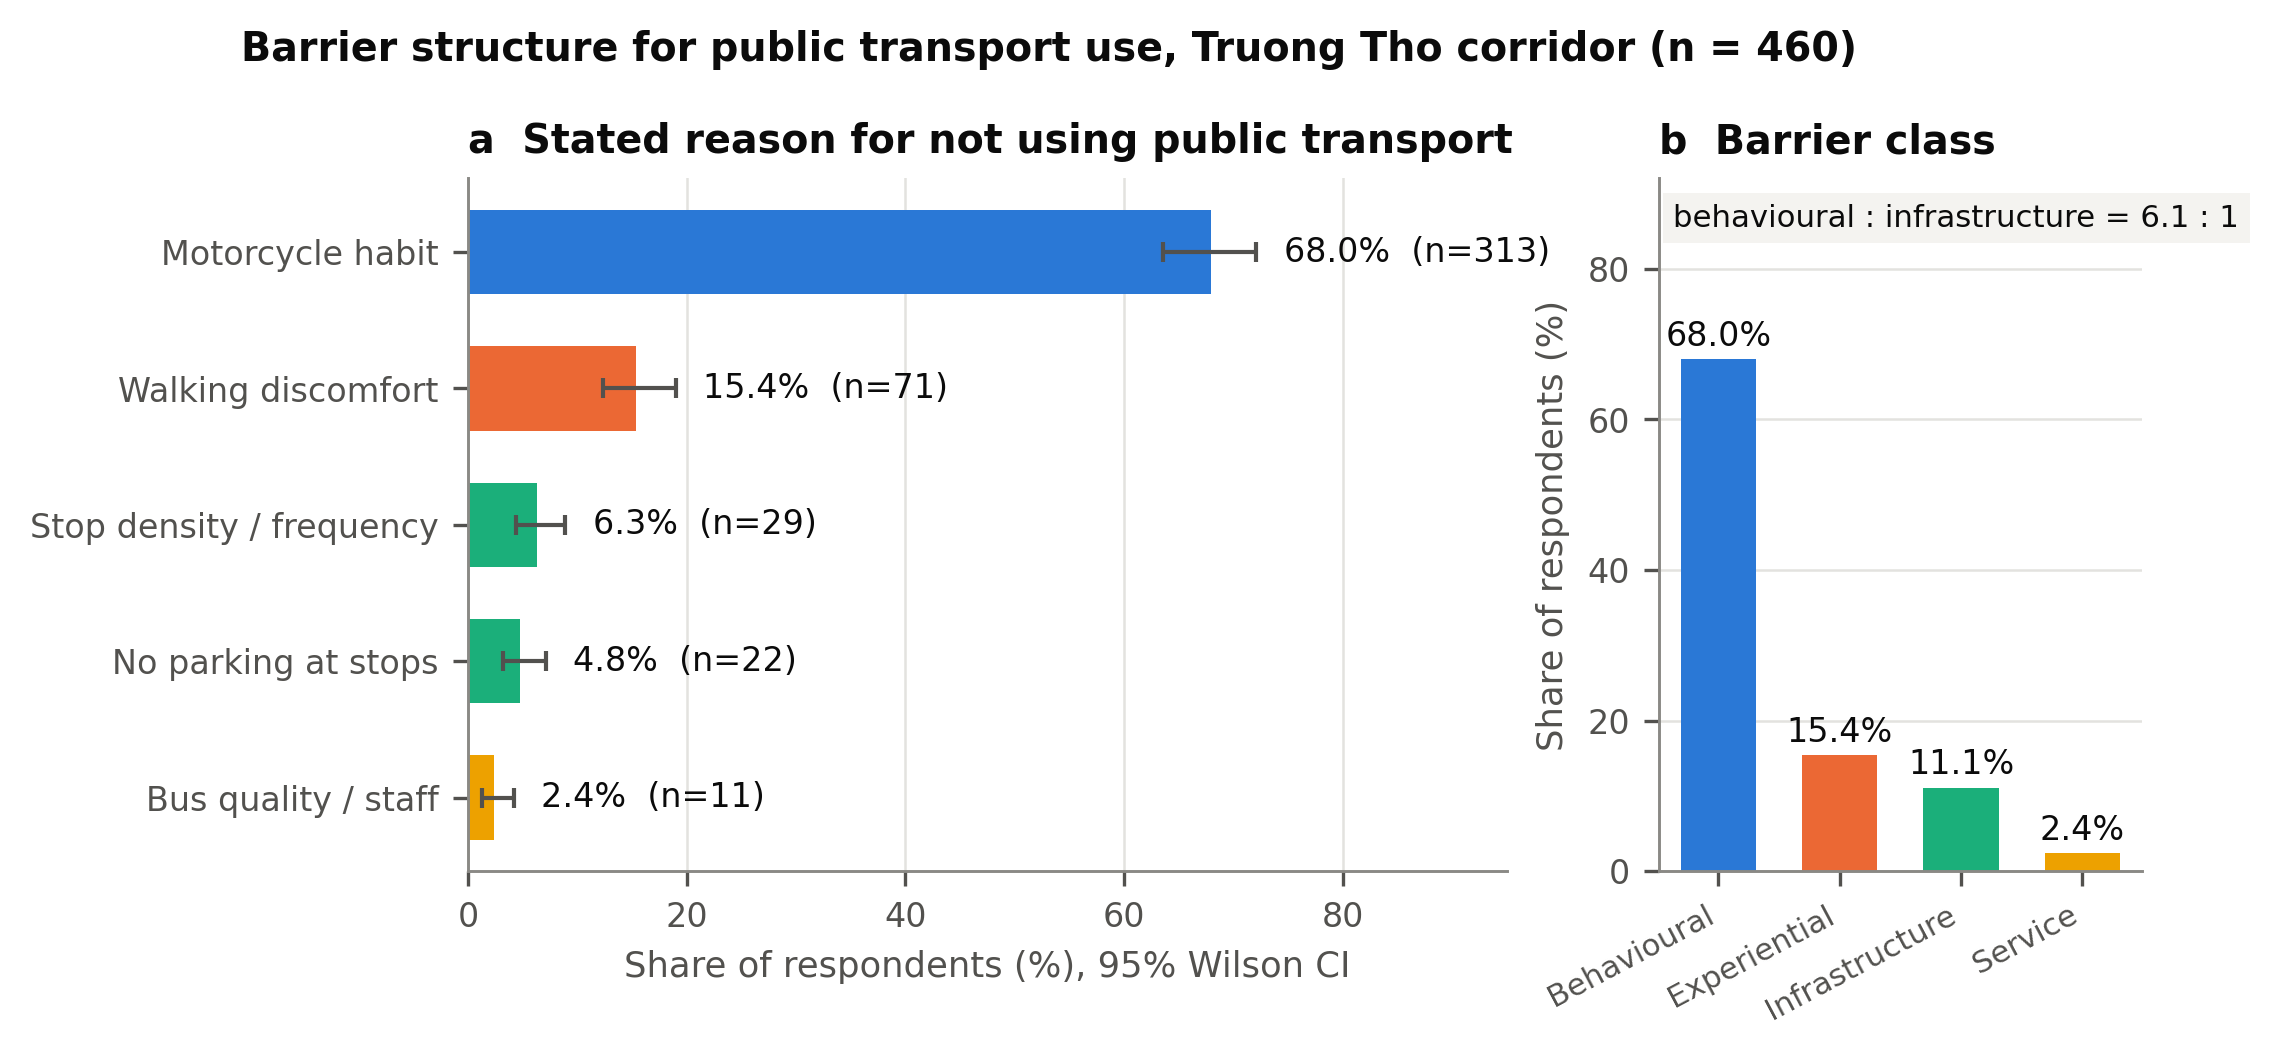

In [13]:
def f1():
    t2 = pd.read_csv(TAB / "T2_barrier_structure.csv")
    t2 = t2[t2.Class != "Not a barrier"].sort_values("n")
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.0),
                                  gridspec_kw={"width_ratios": [2.15, 1]})
    y = np.arange(len(t2))
    lo = np.array([float(s.strip("[]").split(",")[0]) for s in t2["95% CI (all)"]])
    hi = np.array([float(s.strip("[]").split(",")[1]) for s in t2["95% CI (all)"]])
    v = t2["% of all respondents (n=460)"].values
    cols = [CLS[c] for c in t2.Class]
    ax.barh(y, v, color=cols, height=.62)
    ax.errorbar(v, y, xerr=[v-lo, hi-v], fmt="none", ecolor=INK2, elinewidth=1, capsize=2.5)
    for i, (vv, hh, nn) in enumerate(zip(v, hi, t2.n)):
        ax.text(hh+2.5, i, f"{vv:.1f}%  (n={nn})", va="center", fontsize=8, color=INK)
    ax.set_yticks(y); ax.set_yticklabels(t2["Stated reason"], fontsize=8)
    ax.set_xlim(0, 95); ax.set_xlabel("Share of respondents (%), 95% Wilson CI")
    ax.set_title("a  Stated reason for not using public transport", loc="left")
    tidy(ax, xgrid=True, ygrid=False)

    agg = [("Behavioural", R["pct_behav"], S1), ("Experiential", R["pct_walk"], S2),
           ("Infrastructure", R["pct_infra"], S3), ("Service", 100*R["n_serv"]/460, S4)]
    x = np.arange(len(agg))
    ax2.bar(x, [a[1] for a in agg], color=[a[2] for a in agg], width=.62)
    for i, a in enumerate(agg):
        ax2.text(i, a[1]+1.8, f"{a[1]:.1f}%", ha="center", fontsize=8, color=INK)
    ax2.set_xticks(x)
    ax2.set_xticklabels([a[0] for a in agg], fontsize=7.4, rotation=28, ha="right")
    ax2.set_ylim(0, 92); ax2.set_ylabel("Share of respondents (%)")
    ax2.set_title("b  Barrier class", loc="left")
    ax2.annotate(f"behavioural : infrastructure = {R['ratio_behav_infra']} : 1",
                 xy=(.03, .93), xycoords="axes fraction", fontsize=7.4, color=INK,
                 ha="left", bbox=dict(fc="#f4f3f0", ec="none", pad=2.5))
    tidy(ax2)
    fig.suptitle(f"Barrier structure for public transport use, Truong Tho corridor (n = {R['n_citizens']})",
                 fontsize=9.5, fontweight="bold", y=1.045, x=.02, ha="left")
    save(fig, "Figure1_barrier_structure")


f1()
from IPython.display import Image, display
display(Image(str(FIG/'Figure1_barrier_structure.png')))

## 8 · OSM completeness audit — Tables 4–5, Figures 2 and 12

**This audit decides how the before–after comparison may be read.** All fourteen Metro Line 1
stations are already present in the January 2023 snapshot — they were mapped while under
construction — and move by at most a few tens of metres between snapshots. Metro geometry
therefore carries *no* before–after signal. Bus and platform objects, by contrast, grow by
160 %, which mixes genuine new infrastructure with rising OSM completeness and cannot be read
as pure infrastructure delivery.

In [14]:
# ============================================================ T4 OSM completeness audit
m26_l1 = m26.copy()
RENAME = {"Suoi Tien station": "National University", "East Bus Station": "Suoi Tien Terminal"}
m23["match"] = m23.name.str.replace(" station", "", regex=False)
m23["match"] = m23.name.map(lambda s: RENAME.get(s, s.replace(" station", "")))
aud = m23[["match", "lon", "lat"]].rename(columns={"match": "Station (2026 name)",
                                                   "lon": "lon_2023", "lat": "lat_2023"})
aud = aud.merge(m26_l1[["name", "lon", "lat"]].rename(
    columns={"name": "Station (2026 name)", "lon": "lon_2026", "lat": "lat_2026"}),
    on="Station (2026 name)", how="outer")
aud["shift_m"] = (np.hypot((aud.lon_2026-aud.lon_2023)*109000*np.cos(np.radians(10.8)),
                           (aud.lat_2026-aud.lat_2023)*110600)).round(1)
aud["in 2023 snapshot"] = aud.lon_2023.notna().map({True: "yes", False: "no"})
aud["in 2026 snapshot"] = aud.lon_2026.notna().map({True: "yes", False: "no"})
T("T4_metro_station_audit", aud)
R["n_metro_2023"] = int(len(m23)); R["n_metro_2026_line1"] = int(len(m26_l1))
R["metro_max_shift_m"] = float(np.nanmax(aud.shift_m))

comp = []
for tag, lab in [("osm2023", "1 Jan 2023"), ("osm2026", "1 Jan 2026")]:
    tn = pd.DataFrame(json.load(open(OSMDIR / f"transit_nodes_{tag}.json")))
    pn = json.load(open(OSMDIR / f"poi_nodes_{tag}.json"))
    pw = json.load(open(OSMDIR / f"poi_ways_{tag}.json"))
    rd = json.load(open(OSMDIR / f"roads_{tag}.json"))
    comp.append({"Snapshot": lab,
                 "Metro Line 1 stations": len(m23) if tag == "osm2023" else len(m26_l1),
                 "Bus/PT stop objects": int(len(tn)),
                 "  of which highway=bus_stop": int((tn.highway == "bus_stop").sum()),
                 "  of which public_transport=platform": int((tn.public_transport == "platform").sum()),
                 "Commercial POIs": len(pn)+len(pw),
                 "Highway ways": len(rd)})
t5 = pd.DataFrame(comp).set_index("Snapshot").T.reset_index().rename(columns={"index": "OSM object class"})
t5["Change"] = (t5.iloc[:, 2] - t5.iloc[:, 1])
t5["Change %"] = (100*t5.Change/t5.iloc[:, 1]).round(1)
T("T5_osm_completeness_audit", t5)
R["bus_2023"] = int(t5.loc[t5["OSM object class"] == "Bus/PT stop objects"].iloc[0, 1])
R["bus_2026"] = int(t5.loc[t5["OSM object class"] == "Bus/PT stop objects"].iloc[0, 2])
R["bus_growth_pct"] = float(t5.loc[t5["OSM object class"] == "Bus/PT stop objects", "Change %"].iloc[0])


R["med_dbus23"] = round(float(cit.d_bus_m_osm2023.median()), 0)
R["med_dbus26"] = round(float(cit.d_bus_m_osm2026.median()), 0)
aud

,Station (2026 name),lon_2023,lat_2023,lon_2026,lat_2026,shift_m,in 2023 snapshot,in 2026 snapshot
0,An Phu,106.742450,10.802193,106.742245,10.802139,22.7,yes,yes
1,Ba Son,106.708387,10.781975,106.708406,10.782034,6.9,yes,yes
2,Ben Thanh,106.697483,10.770829,106.697543,10.770827,6.4,yes,yes
3,Binh Thai,106.763788,10.832679,106.763900,10.832664,12.1,yes,yes
4,High Tech Park,106.788778,10.859100,106.788833,10.858992,13.3,yes,yes
5,National University,106.800932,10.866187,106.801201,10.866301,31.4,yes,yes
6,Opera House,106.702242,10.775547,106.702204,10.775570,4.7,yes,yes
7,Phuoc Long,106.758054,10.821166,106.758181,10.821427,31.8,yes,yes
8,Rach Chiec,106.755314,10.808702,106.755268,10.808548,17.7,yes,yes
9,Suoi Tien Terminal,106.814208,10.879689,106.814110,10.879575,16.4,yes,yes


   Figure2_accessibility_map
   Figure12_osm_audit


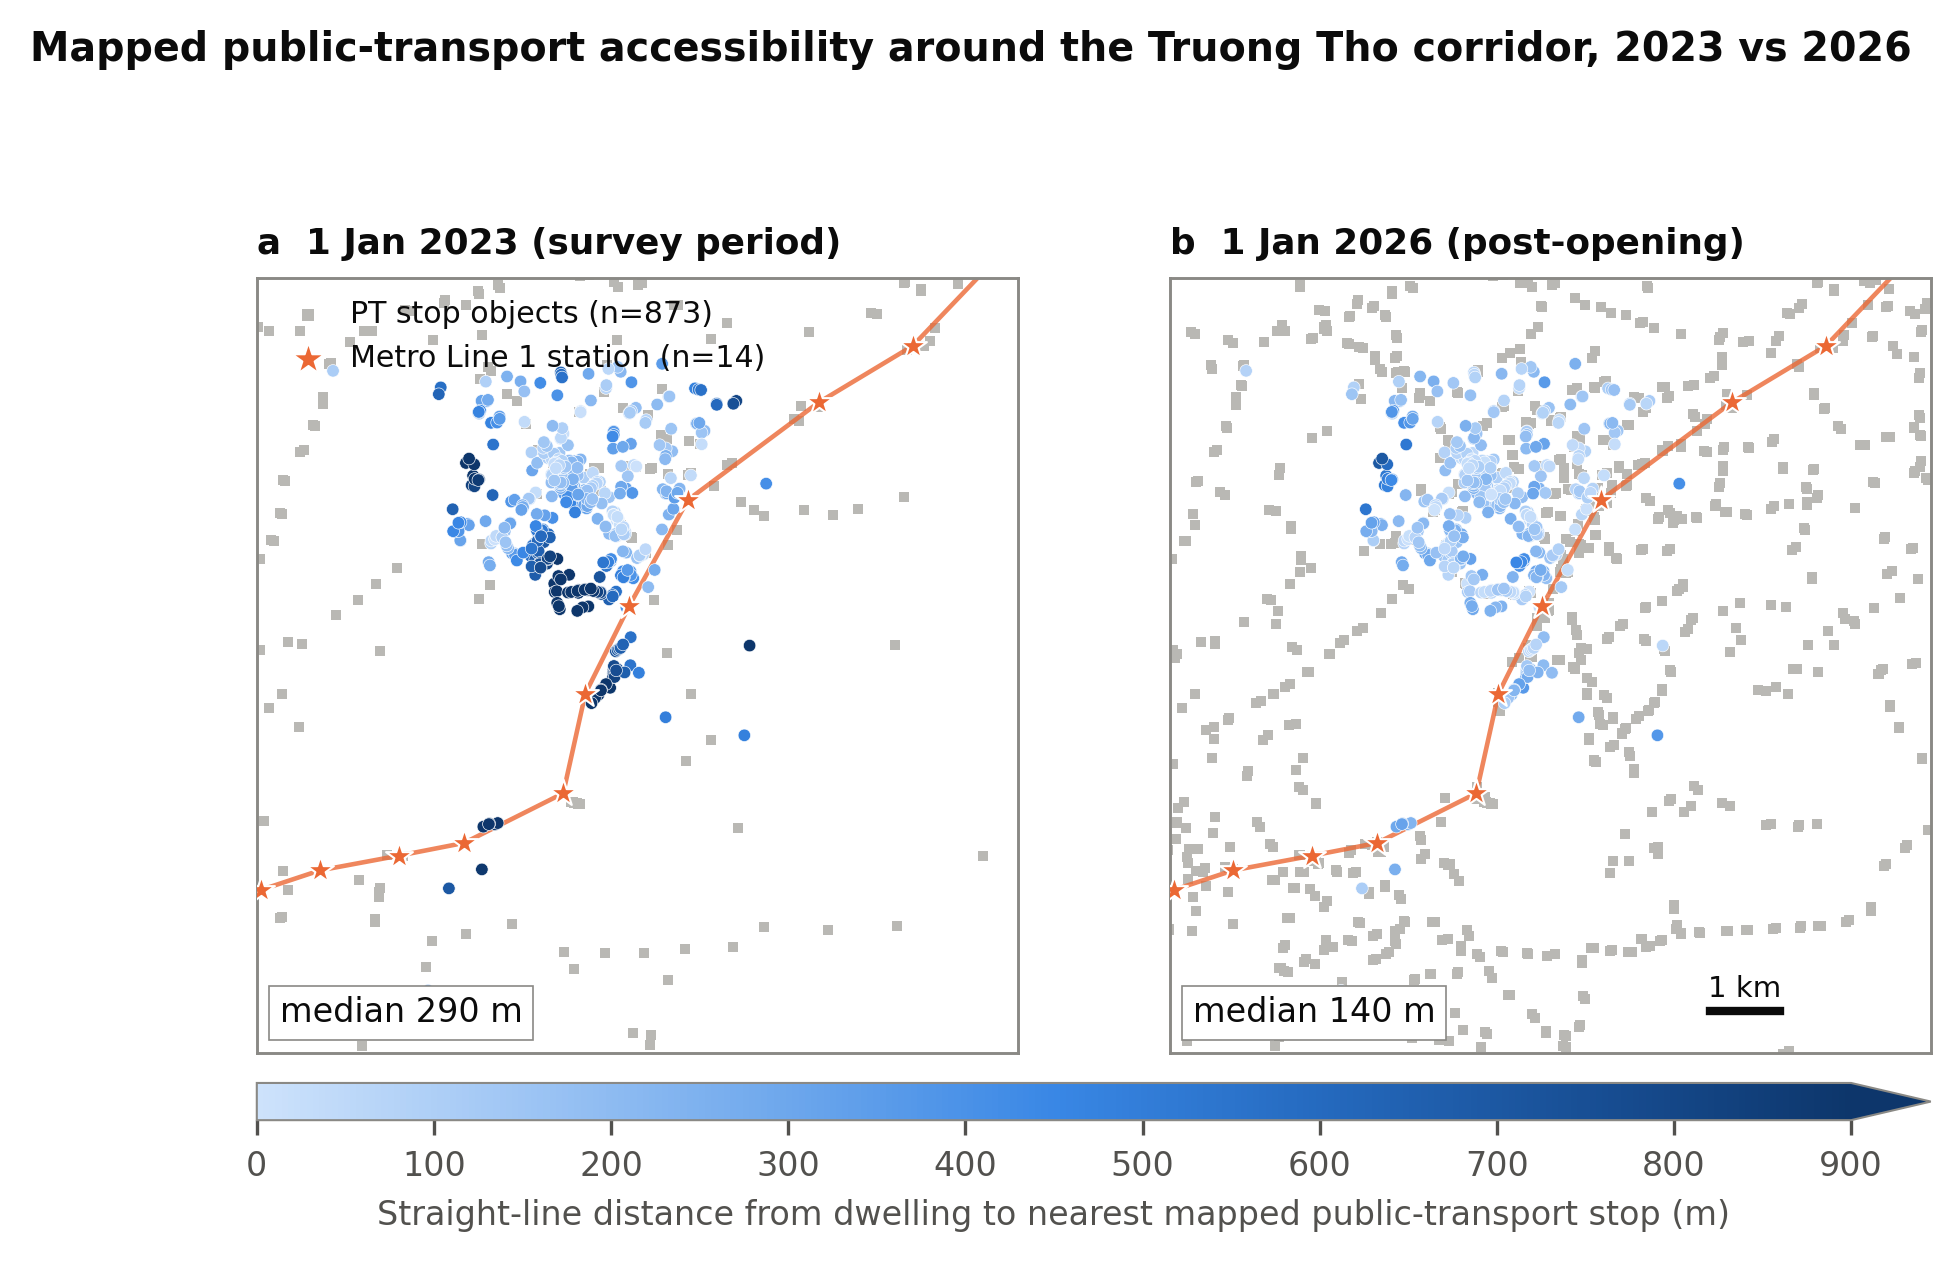

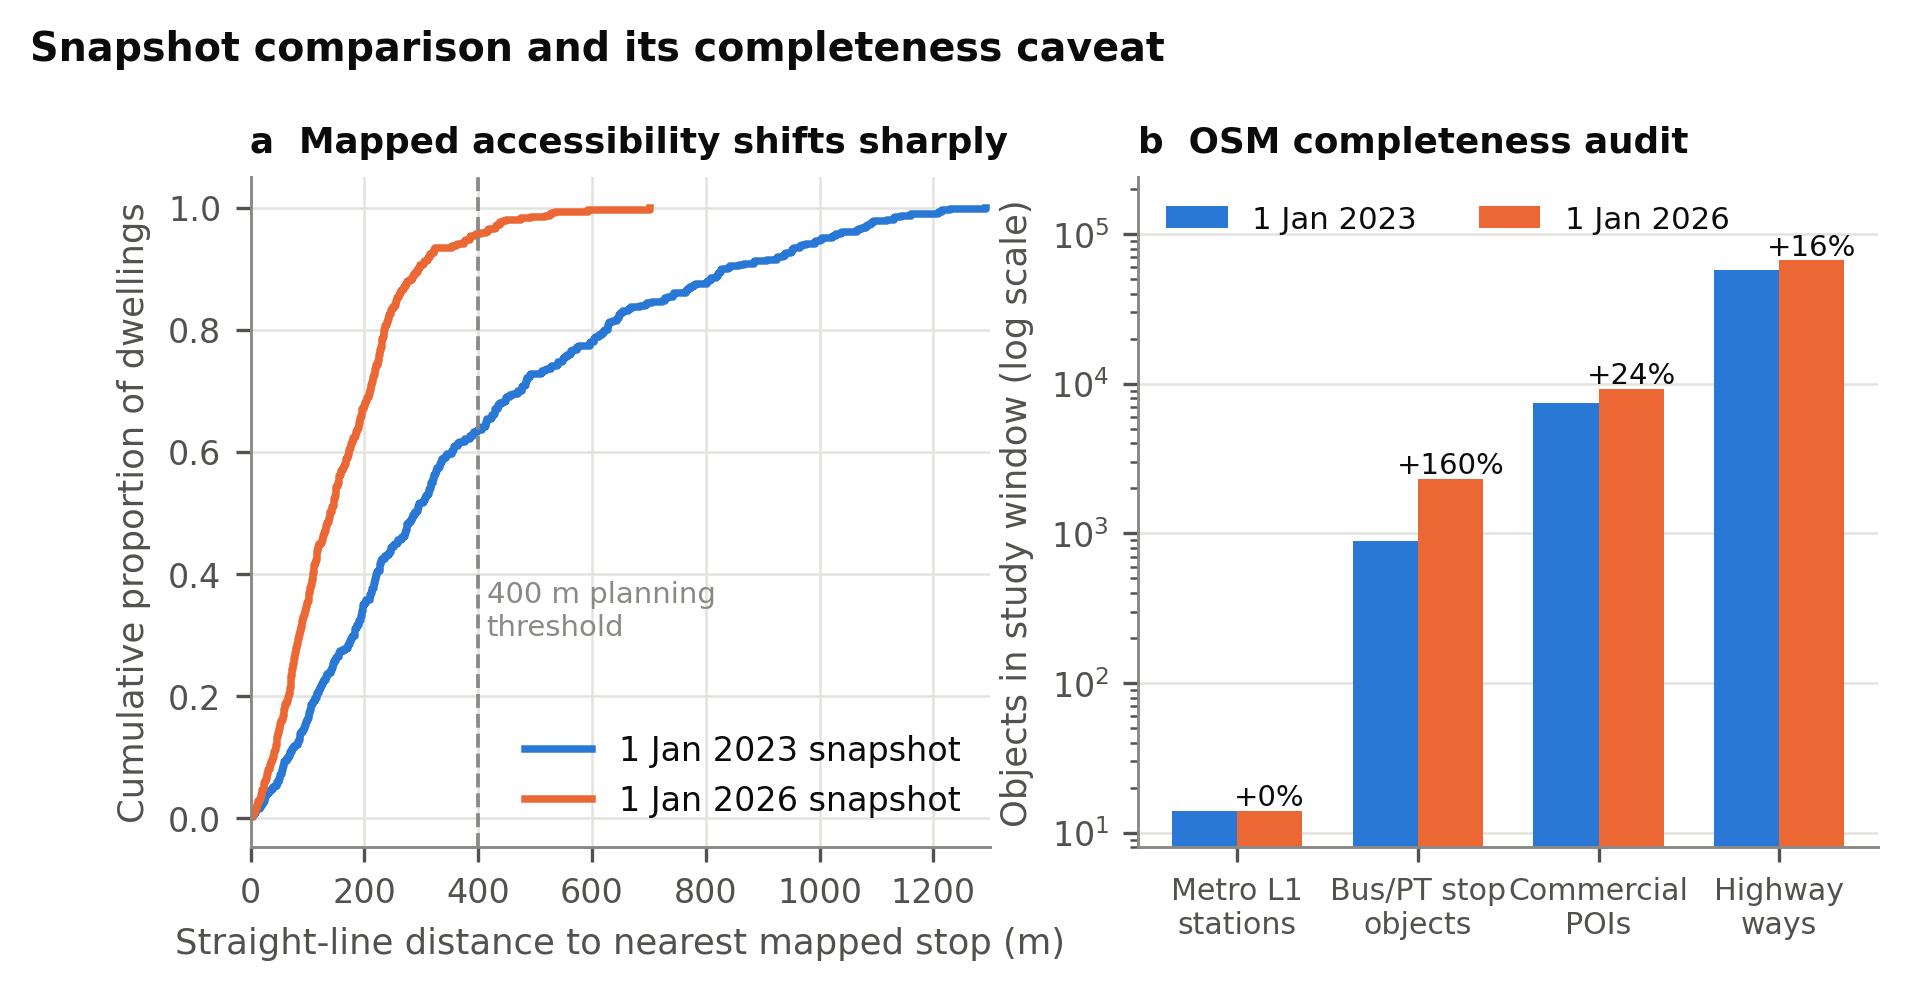

In [15]:
def f2():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.3))
    for ax, (tag, bs, ttl) in zip(axes, [
            ("osm2023", b23, "a  1 Jan 2023 (survey period)"),
            ("osm2026", b26, "b  1 Jan 2026 (post-opening)")]):
        d = cit
        ax.scatter(bs.lon, bs.lat, s=5, c="#b9b8b4", marker="s", lw=0, zorder=1,
                   label=f"PT stop objects (n={len(bs)})")
        sc = ax.scatter(d.Long, d.Lat, c=d[f"d_bus_m_{tag}"], cmap=SEQ, s=9, lw=.15,
                        edgecolor="white", vmin=0, vmax=900, zorder=3)
        ax.scatter(m26.lon, m26.lat, s=46, marker="*", c=S2, lw=.5, edgecolor="white",
                   zorder=4, label="Metro Line 1 station (n=14)")
        ax.plot(m26.lon, m26.lat, c=S2, lw=1.1, zorder=2, alpha=.8)
        ax.set_xlim(106.715, 106.815); ax.set_ylim(10.775, 10.875)
        ax.set_aspect(1/np.cos(np.radians(10.82)))
        ax.set_title(ttl, loc="left", fontsize=8.6)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(True); s.set_color(MUT)
        ax.text(.03, .04, f"median {R['med_dbus23'] if tag=='osm2023' else R['med_dbus26']:.0f} m",
                transform=ax.transAxes, fontsize=8, color=INK,
                bbox=dict(fc="white", ec=MUT, lw=.4, pad=2.5))
    cb = fig.colorbar(sc, ax=axes, fraction=.05, pad=.03, extend="max",
                      orientation="horizontal", aspect=45)
    cb.set_label("Straight-line distance from dwelling to nearest mapped public-transport stop (m)",
                 fontsize=8)
    cb.outline.set_edgecolor(MUT); cb.outline.set_linewidth(.5)
    axes[0].legend(loc="upper left", fontsize=7.2, markerscale=1.2,
                   handletextpad=.4, borderpad=.2)
    # scale bar
    ax = axes[1]
    x0, y0 = 106.786, 10.7805
    dlon = 1000/(111320*np.cos(np.radians(10.82)))
    ax.plot([x0, x0+dlon], [y0, y0], c=INK, lw=2)
    ax.text(x0+dlon/2, y0+.0018, "1 km", ha="center", fontsize=7, color=INK)
    fig.suptitle("Mapped public-transport accessibility around the Truong Tho corridor, 2023 vs 2026",
                 fontsize=9.5, fontweight="bold", y=.965, x=.02, ha="left")
    save(fig, "Figure2_accessibility_map")

def f12():
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.9))
    for var, c, nm in [("d_bus_m_osm2023", S1, "1 Jan 2023 snapshot"),
                       ("d_bus_m_osm2026", S2, "1 Jan 2026 snapshot")]:
        d = np.sort(cit[var].dropna().values)
        ax.step(d, np.arange(1, len(d)+1)/len(d), color=c, lw=1.8, where="post", label=nm)
    ax.axvline(400, color=MUT, ls="--", lw=.9)
    ax.text(415, .30, "400 m planning\nthreshold", fontsize=7, color=MUT)
    ax.set_xlabel("Straight-line distance to nearest mapped stop (m)")
    ax.set_ylabel("Cumulative proportion of dwellings")
    ax.set_xlim(0, 1300); ax.legend(loc="lower right")
    ax.set_title("a  Mapped accessibility shifts sharply", loc="left", fontsize=8.6)
    tidy(ax, xgrid=True, ygrid=True)

    t5 = pd.read_csv(f"{TAB}/T5_osm_completeness_audit.csv")
    keep = ["Metro Line 1 stations", "Bus/PT stop objects", "Commercial POIs", "Highway ways"]
    t5 = t5[t5["OSM object class"].isin(keep)]
    x = np.arange(len(t5)); w = .36
    ax2.bar(x-w/2, t5.iloc[:, 1], width=w, color=S1, label="1 Jan 2023")
    ax2.bar(x+w/2, t5.iloc[:, 2], width=w, color=S2, label="1 Jan 2026")
    for i, (a, b) in enumerate(zip(t5.iloc[:, 1], t5.iloc[:, 2])):
        ax2.text(i+w/2, b*1.08, f"+{100*(b-a)/a:.0f}%", ha="center", fontsize=7, color=INK)
    ax2.set_yscale("log"); ax2.set_ylim(8, 2.4e5)
    ax2.set_xticks(x); ax2.set_xticklabels(["Metro L1\nstations", "Bus/PT stop\nobjects",
                                            "Commercial\nPOIs", "Highway\nways"], fontsize=7.2)
    ax2.set_ylabel("Objects in study window (log scale)")
    ax2.legend(fontsize=7.4, ncol=2, loc="upper left")
    ax2.set_title("b  OSM completeness audit", loc="left", fontsize=8.6)
    tidy(ax2)
    fig.suptitle("Snapshot comparison and its completeness caveat",
                 fontsize=9.5, fontweight="bold", y=1.05, x=.02, ha="left")
    save(fig, "Figure12_osm_audit")

f2(); f12()
display(Image(str(FIG/'Figure2_accessibility_map.png')))
display(Image(str(FIG/'Figure12_osm_audit.png')))

## 9 · The two central tests — Tables 6–8, Figures 3–5

**Test A (cross-sectional, robust).** Does objective accessibility differ by the barrier a
respondent names? This test uses a *single* snapshot, so it is immune to the completeness
problem above. If people who cite infrastructure do not in fact live further from stops, the
stated reasons are not descriptions of physical conditions.

**Test B (before–after, caveated).** Did the accessibility gain land on the people who named
infrastructure? Read together with the audit, this bounds how much targeting could have
occurred.

**Test C.** The 71 respondents who say walking to stops is uncomfortable are the pivotal
group: if their walks are objectively no worse, the barrier is perceptual and they belong with
the habit group, which changes the headline ratio.

In [16]:
# ============================================================ T6 accessibility 2023 vs 2026
g = cit[cit.d_bus_m_osm2023.notna()].copy()
rows = []
for lab, a, b in [("Straight-line distance to nearest PT stop (m)", "d_bus_m_osm2023", "d_bus_m_osm2026"),
                  ("Network walking distance to nearest PT stop (m)", "net_dist_bus_m_osm2023", "net_dist_bus_m_osm2026"),
                  ("Detour ratio (network / straight-line)", "detour_ratio_osm2023", "detour_ratio_osm2026"),
                  ("Commercial POIs within 1 km", "poi_1000m_osm2023", "poi_1000m_osm2026")]:
    x, y = g[a].dropna(), g[b].dropna()
    both = g[[a, b]].dropna()
    w = stats.wilcoxon(both[a], both[b])
    rows.append({"Variable": lab,
                 "2023 median [IQR]": f"{x.median():.2f} [{x.quantile(.25):.2f}–{x.quantile(.75):.2f}]",
                 "2026 median [IQR]": f"{y.median():.2f} [{y.quantile(.25):.2f}–{y.quantile(.75):.2f}]",
                 "Median change": round(float((both[b]-both[a]).median()), 2),
                 "Wilcoxon p": f"{w.pvalue:.3g}"})
rows.append({"Variable": "Straight-line distance to nearest Metro Line 1 station (m)",
             "2023 median [IQR]": f"{g.d_metro_m_osm2023.median():.0f} [{g.d_metro_m_osm2023.quantile(.25):.0f}–{g.d_metro_m_osm2023.quantile(.75):.0f}]",
             "2026 median [IQR]": f"{g.d_metro_m_osm2026.median():.0f} [{g.d_metro_m_osm2026.quantile(.25):.0f}–{g.d_metro_m_osm2026.quantile(.75):.0f}]",
             "Median change": round(float((g.d_metro_m_osm2026-g.d_metro_m_osm2023).median()), 2),
             "Wilcoxon p": "n.a. (stations mapped in both snapshots)"})
t6 = T("T6_accessibility_change", pd.DataFrame(rows))
R["med_dbus23"] = round(float(g.d_bus_m_osm2023.median()), 0)
R["med_dbus26"] = round(float(g.d_bus_m_osm2026.median()), 0)
R["med_net23"] = round(float(g.net_dist_bus_m_osm2023.median()), 0)
R["med_net26"] = round(float(g.net_dist_bus_m_osm2026.median()), 0)
R["med_delta"] = round(float(g.delta_access_m.median()), 0)
R["med_detour23"] = round(float(g.detour_ratio_osm2023.median()), 2)
R["med_dmetro"] = round(float(g.d_metro_m_osm2026.median()), 0)
R["n_treated"] = int((g.d_metro_m_osm2026 < 1000).sum())
R["pct_treated"] = round(100*(g.d_metro_m_osm2026 < 1000).mean(), 1)

# ============================================================ T7 the two central tests
GRP = ["Motorcycle habit", "Walking discomfort", "Stop density / frequency",
       "No parking at stops", "Bus quality / staff"]
gg = g[g.reason_en.isin(GRP)].copy()

def kw_table(df, var, groups=GRP, label=""):
    samples = [df.loc[df.reason_en == k, var].dropna().values for k in groups]
    H, p = stats.kruskal(*samples)
    eps2 = (H - len(groups) + 1) / (sum(len(s) for s in samples) - len(groups))
    out = {"Variable": label or var, "H": round(H, 2), "df": len(groups)-1,
           "p": f"{p:.3f}", "epsilon^2": round(eps2, 3)}
    for k, s in zip(groups, samples):
        out[k] = f"{np.median(s):.2f} (n={len(s)})"
    return out, p

rows = []
for var, lab in [("d_bus_m_osm2023", "2023 straight-line distance to nearest PT stop (m)"),
                 ("net_dist_bus_m_osm2023", "2023 network walking distance to stop (m)"),
                 ("detour_ratio_osm2023", "2023 detour ratio"),
                 ("d_metro_m_osm2026", "Distance to nearest Metro Line 1 station (m)"),
                 ("delta_access_m", "Change in mapped PT accessibility 2023-2026 (m)"),
                 ("poi_1000m_osm2023", "Commercial POIs within 1 km (2023)"),
                 ("road_density", "Road density within 500 m (m/km2)")]:
    r, p = kw_table(gg, var, label=lab); rows.append(r)
t7 = T("T7_central_tests", pd.DataFrame(rows))
R["kw"] = {r["Variable"]: {"H": r["H"], "p": r["p"], "eps2": r["epsilon^2"]} for r in rows}

# ---- T8 walking-discomfort group vs the rest (Mann-Whitney)
rows = []
walk = g.reason_en == "Walking discomfort"
rest = g.reason_en.isin([k for k in GRP if k != "Walking discomfort"])
for var, lab in [("d_bus_m_osm2023", "2023 straight-line distance to stop (m)"),
                 ("net_dist_bus_m_osm2023", "2023 network walking distance (m)"),
                 ("detour_ratio_osm2023", "2023 detour ratio"),
                 ("net_dist_bus_m_osm2026", "2026 network walking distance (m)"),
                 ("detour_ratio_osm2026", "2026 detour ratio"),
                 ("road_density", "Road density within 500 m (m/km2)")]:
    a = g.loc[walk, var].dropna(); b = g.loc[rest, var].dropna()
    U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    cles = U/(len(a)*len(b))                       # prob. a random 'walk' case exceeds a random 'rest' case
    rows.append({"Variable": lab, "Walking-discomfort median (n=%d)" % len(a): round(float(a.median()), 2),
                 "Other barrier groups median (n=%d)" % len(b): round(float(b.median()), 2),
                 "U": int(U), "p": f"{p:.3f}", "Rank-biserial r": round(2*cles-1, 3)})
t8 = T("T8_walking_discomfort", pd.DataFrame(rows))
R["walk_tests"] = {r["Variable"]: r["p"] for r in rows}


t7

,Variable,H,df,p,epsilon^2,Motorcycle habit,Walking discomfort,Stop density / frequency,No parking at stops,Bus quality / staff
0,2023 straight-line distance to nearest PT stop...,8.48,4,0.075,0.010,270.03 (n=313),293.36 (n=71),413.36 (n=29),289.60 (n=21),198.53 (n=11)
1,2023 network walking distance to stop (m),6.70,4,0.153,0.006,388.01 (n=312),450.13 (n=71),550.78 (n=29),415.14 (n=21),436.07 (n=11)
2,2023 detour ratio,5.70,4,0.223,0.004,1.42 (n=312),1.43 (n=71),1.43 (n=29),1.33 (n=21),1.58 (n=11)
3,Distance to nearest Metro Line 1 station (m),19.02,4,0.001,0.034,1676.31 (n=313),1437.08 (n=71),1453.11 (n=29),881.62 (n=21),1447.86 (n=11)
4,Change in mapped PT accessibility 2023-2026 (m),11.61,4,0.021,0.017,89.71 (n=313),95.16 (n=71),234.45 (n=29),146.15 (n=21),27.23 (n=11)
5,Commercial POIs within 1 km (2023),7.02,4,0.135,0.007,74.00 (n=313),76.00 (n=71),38.00 (n=29),79.00 (n=21),92.00 (n=11)
6,Road density within 500 m (m/km2),4.29,4,0.368,0.001,22165.70 (n=313),22470.97 (n=71),23710.91 (n=29),21512.49 (n=21),21674.84 (n=11)


   Figure3_central_test
   Figure4_walking_discomfort
   Figure5_delta_access_by_reason


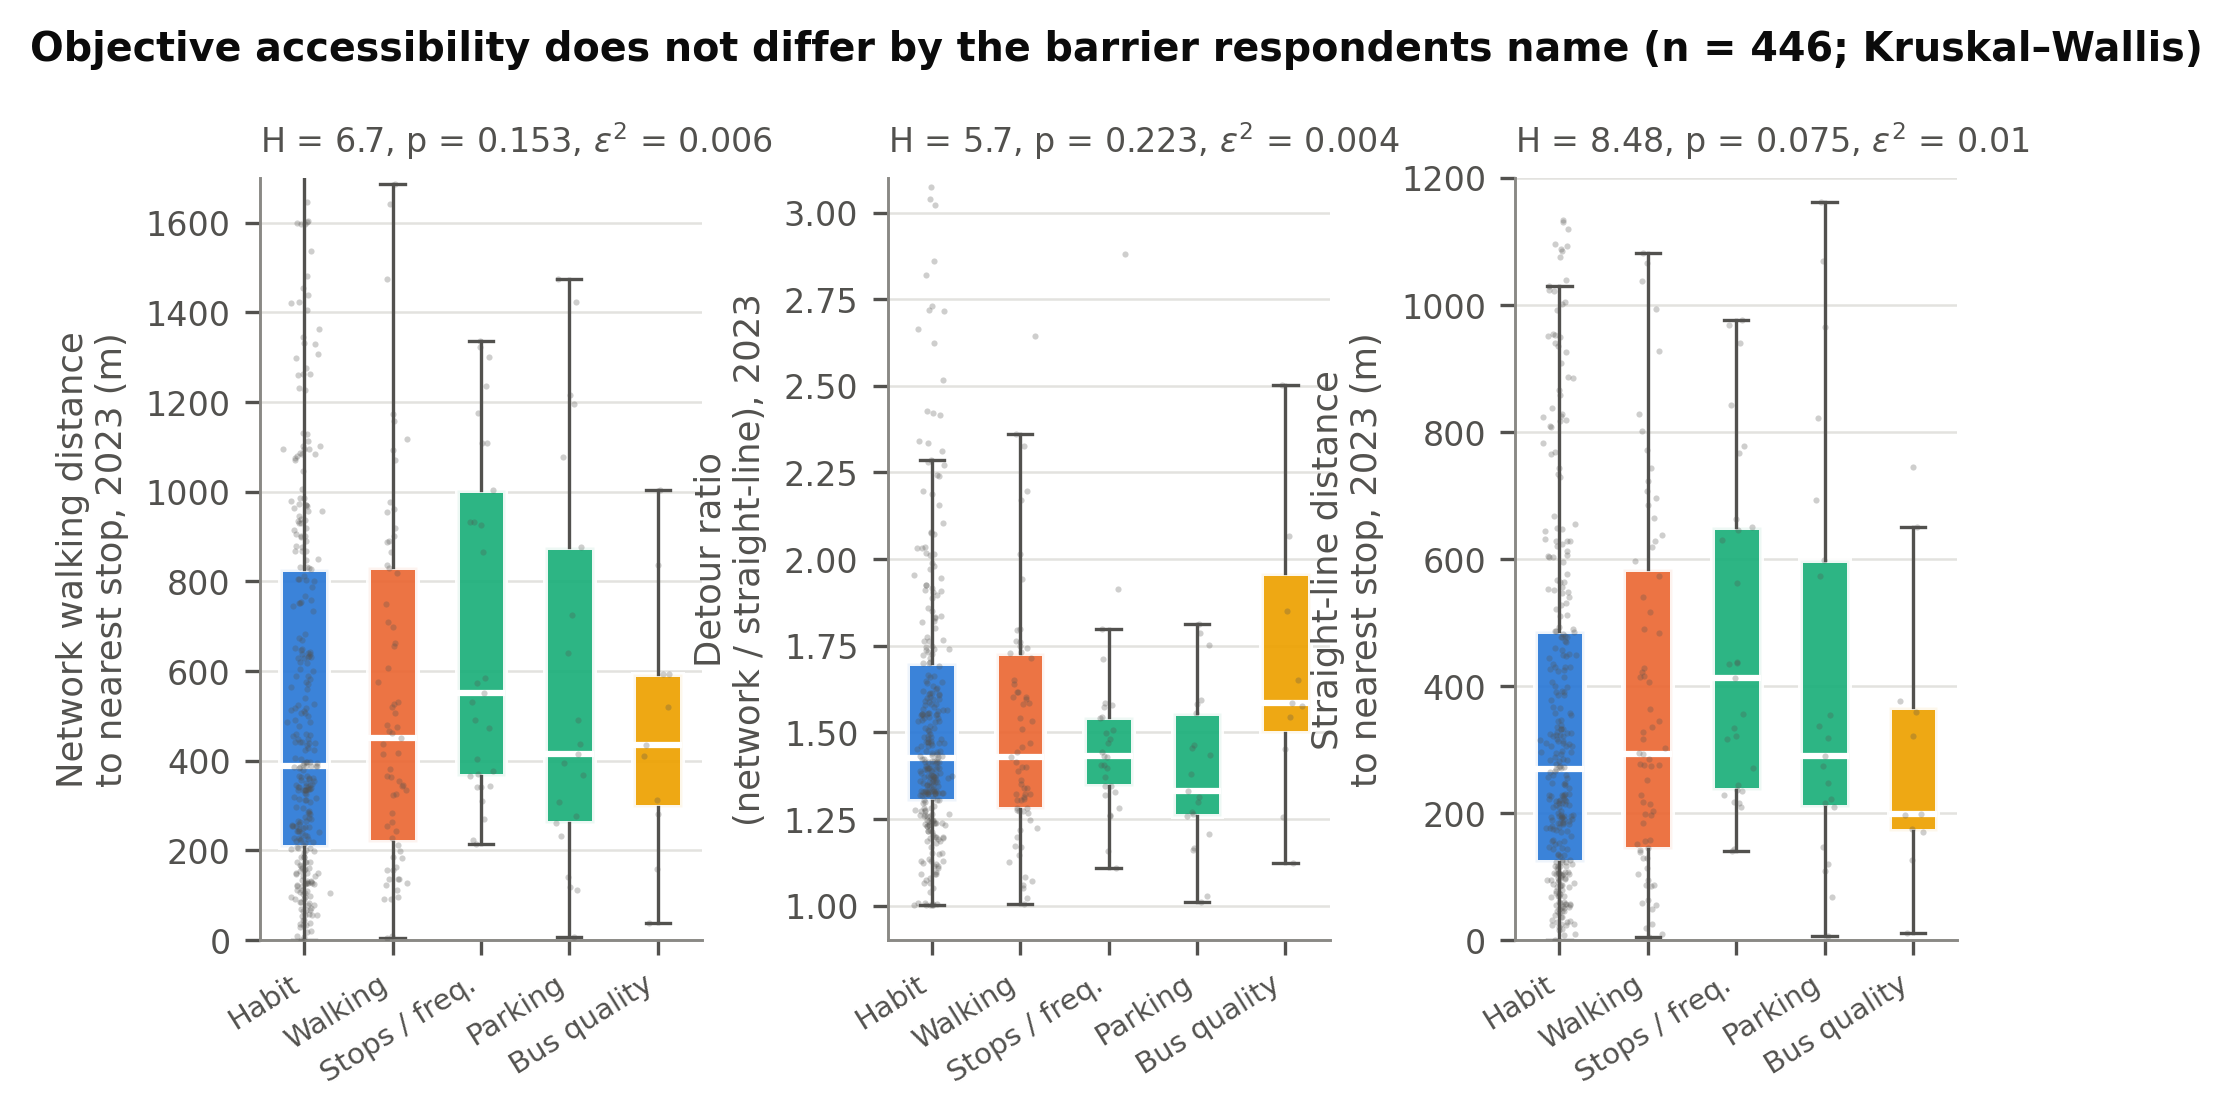

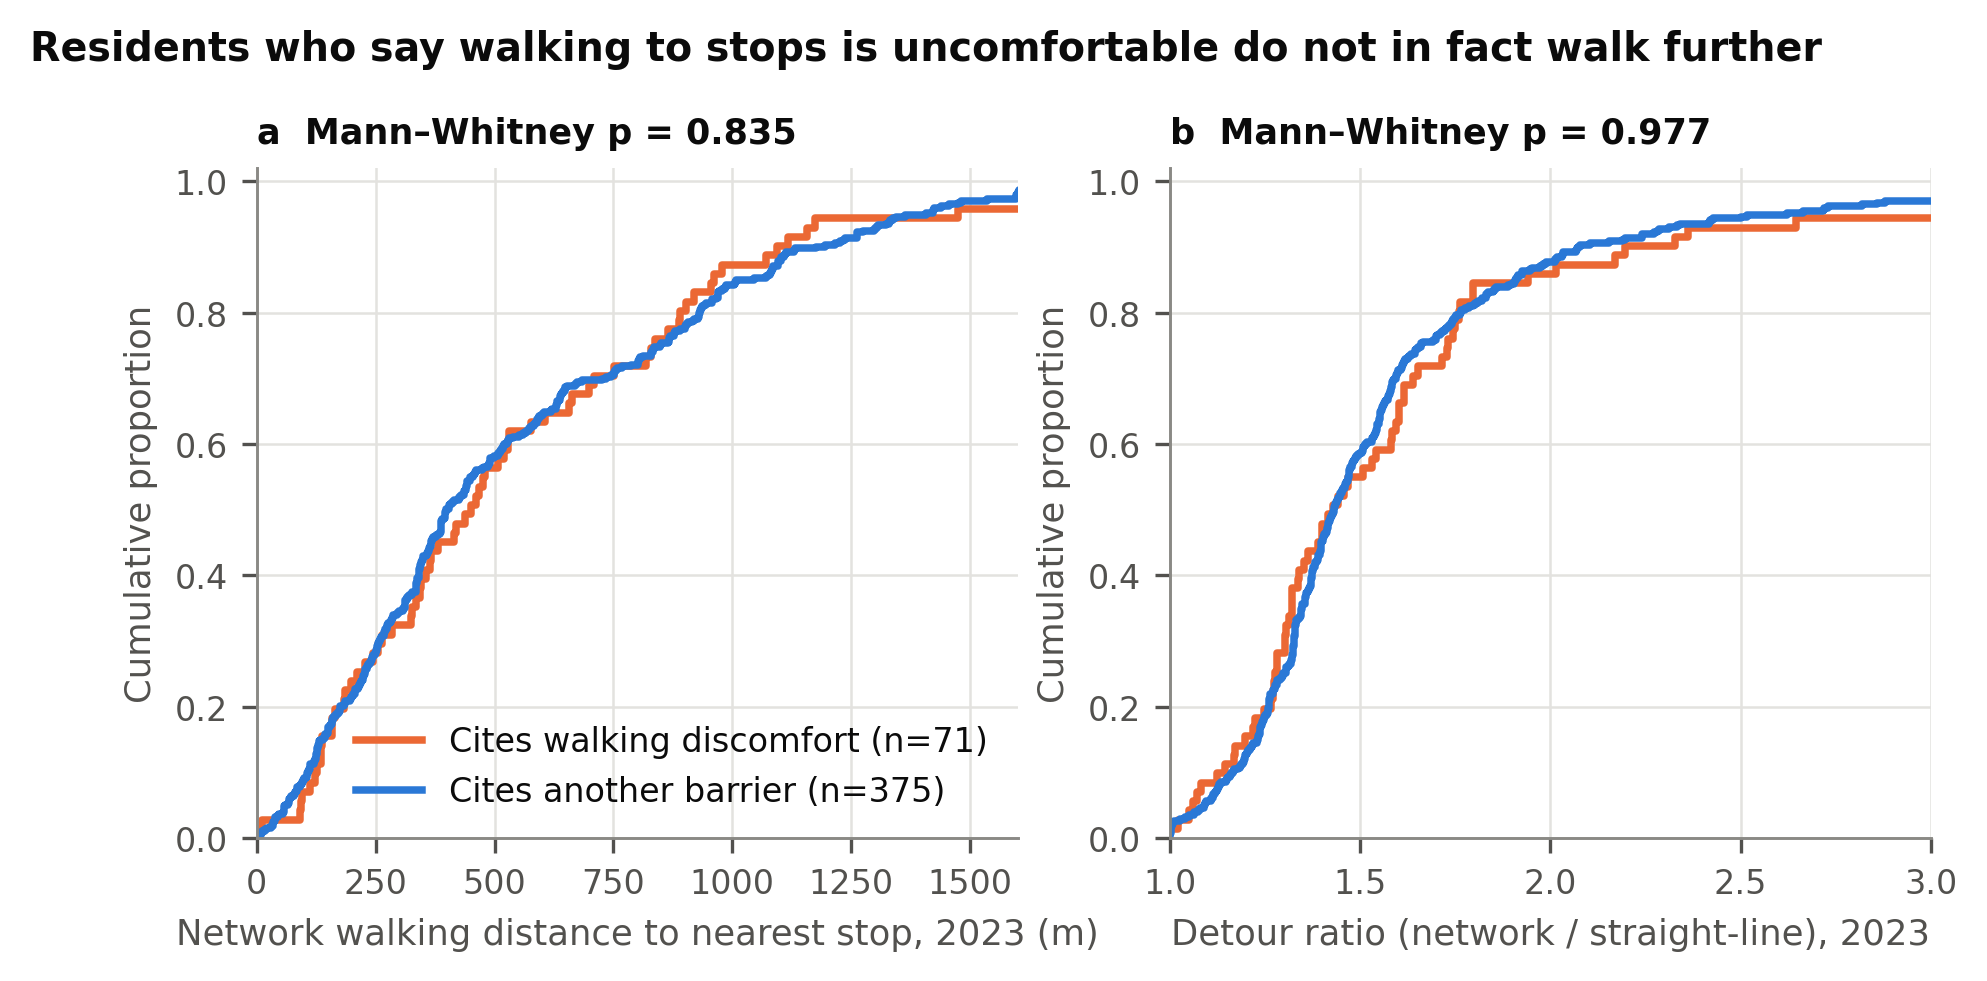

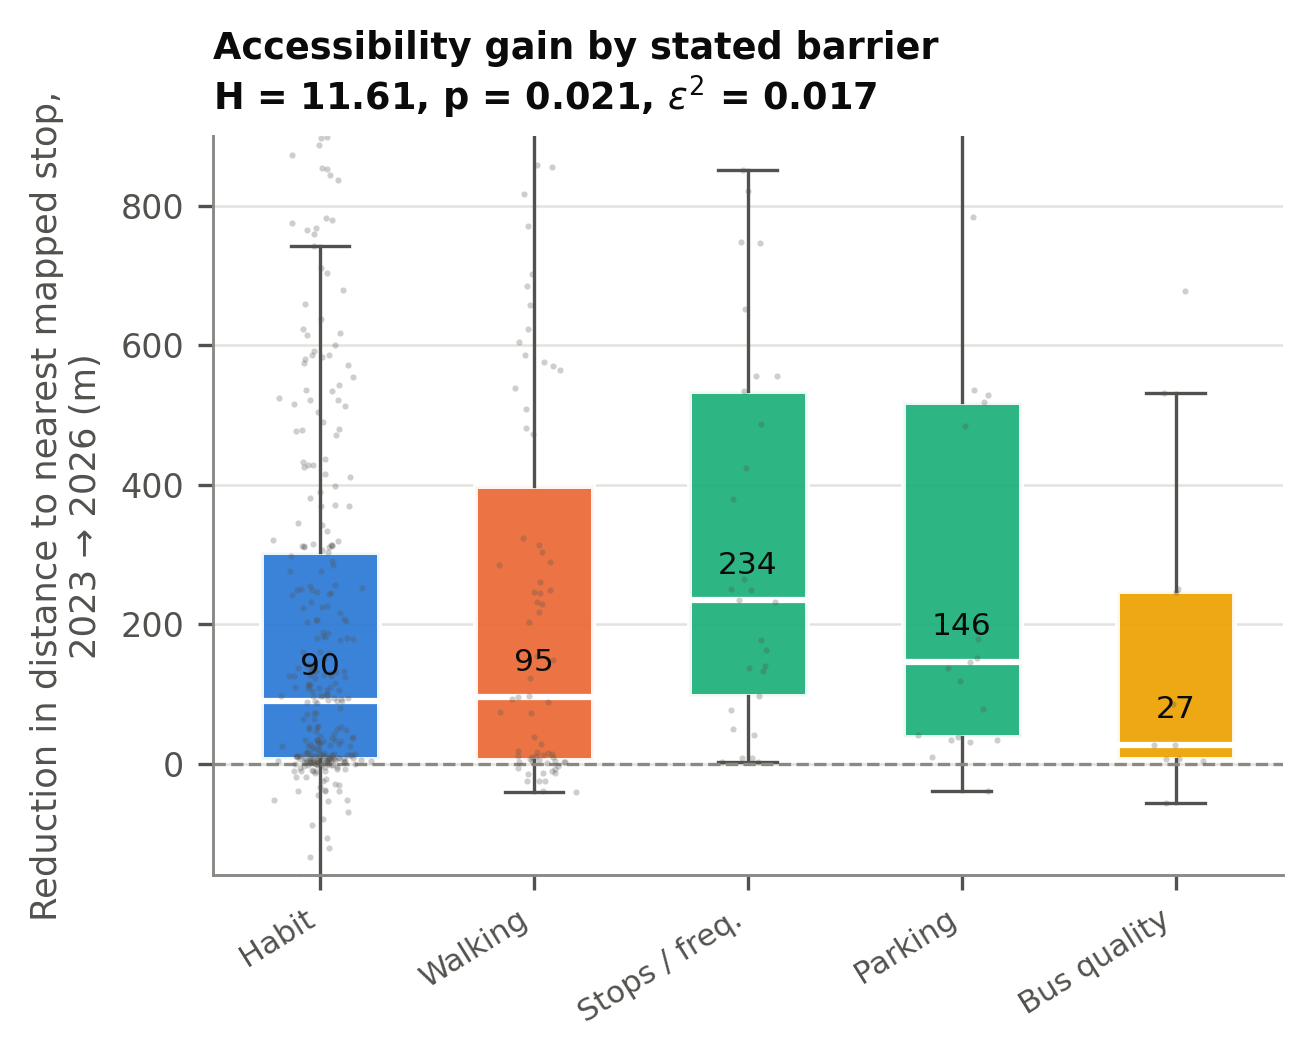

In [17]:
def f3():
    fig, axes = plt.subplots(1, 3, figsize=(7.3, 3.3))
    fig.subplots_adjust(wspace=.42)
    specs = [("net_dist_bus_m_osm2023", "Network walking distance\nto nearest stop, 2023 (m)", (0, 1700)),
             ("detour_ratio_osm2023", "Detour ratio\n(network / straight-line), 2023", (.9, 3.1)),
             ("d_bus_m_osm2023", "Straight-line distance\nto nearest stop, 2023 (m)", (0, 1200))]
    kwkeys = ["2023 network walking distance to stop (m)", "2023 detour ratio",
              "2023 straight-line distance to nearest PT stop (m)"]
    for ax, (var, lab, ylim), kk in zip(axes, specs, kwkeys):
        data = [cit.loc[cit.reason_en == k, var].dropna().values for k in GRP]
        bp = ax.boxplot(data, widths=.55, patch_artist=True, showfliers=False,
                        medianprops=dict(color="white", lw=1.5),
                        whiskerprops=dict(color=INK2, lw=.8),
                        capprops=dict(color=INK2, lw=.8))
        for p, c in zip(bp["boxes"], GCOL):
            p.set(facecolor=c, edgecolor="white", lw=1.2, alpha=.92)
        for i, d in enumerate(data):
            xj = np.random.normal(i+1, .075, len(d))
            ax.scatter(xj, d, s=2.2, c=INK2, alpha=.28, lw=0, zorder=3)
        ax.set_xticks(range(1, 6))
        ax.set_xticklabels(GRP_SHORT, fontsize=7, rotation=32, ha="right")
        ax.set_ylabel(lab); ax.set_ylim(*ylim)
        st = R["kw"][kk]
        ax.set_title(f"H = {st['H']}, p = {st['p']}, $\\epsilon^2$ = {st['eps2']}",
                     loc="left", fontsize=8, fontweight="normal", color=INK2)
        tidy(ax)
    fig.suptitle("Objective accessibility does not differ by the barrier respondents name "
                 f"(n = {len(cit[cit.reason_en.isin(GRP)])}; Kruskal–Wallis)",
                 fontsize=9.5, fontweight="bold", y=1.03, x=.02, ha="left")
    save(fig, "Figure3_central_test")

# ================================================================ F4 walking discomfort
def f4():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    walk = cit.reason_en == "Walking discomfort"
    rest = cit.reason_en.isin([k for k in GRP if k != "Walking discomfort"])
    for ax, (var, lab, xlim) in zip(axes, [
            ("net_dist_bus_m_osm2023", "Network walking distance to nearest stop, 2023 (m)", (0, 1600)),
            ("detour_ratio_osm2023", "Detour ratio (network / straight-line), 2023", (1, 3))]):
        for m, c, nm in [(walk, S2, f"Cites walking discomfort (n={int(walk.sum())})"),
                         (rest, S1, f"Cites another barrier (n={int(rest.sum())})")]:
            d = np.sort(cit.loc[m, var].dropna().values)
            ax.step(d, np.arange(1, len(d)+1)/len(d), color=c, lw=1.8, where="post", label=nm)
        ax.set_xlabel(lab); ax.set_ylabel("Cumulative proportion")
        ax.set_xlim(*xlim); ax.set_ylim(0, 1.02)
        tidy(ax, xgrid=True, ygrid=True)
    p1 = R["walk_tests"]["2023 network walking distance (m)"]
    p2 = R["walk_tests"]["2023 detour ratio"]
    axes[0].set_title(f"a  Mann–Whitney p = {p1}", loc="left", fontsize=8.4)
    axes[1].set_title(f"b  Mann–Whitney p = {p2}", loc="left", fontsize=8.4)
    axes[0].legend(loc="lower right")
    fig.suptitle("Residents who say walking to stops is uncomfortable do not in fact walk further",
                 fontsize=9.5, fontweight="bold", y=1.04, x=.02, ha="left")
    save(fig, "Figure4_walking_discomfort")

# ================================================================ F5 delta access
def f5():
    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    data = [cit.loc[cit.reason_en == k, "delta_access_m"].dropna().values for k in GRP]
    bp = ax.boxplot(data, widths=.55, patch_artist=True, showfliers=False,
                    medianprops=dict(color="white", lw=1.5),
                    whiskerprops=dict(color=INK2, lw=.8), capprops=dict(color=INK2, lw=.8))
    for p, c in zip(bp["boxes"], GCOL):
        p.set(facecolor=c, edgecolor="white", lw=1.2, alpha=.92)
    for i, d in enumerate(data):
        ax.scatter(np.random.normal(i+1, .075, len(d)), d, s=2.2, c=INK2, alpha=.28, lw=0, zorder=3)
        ax.text(i+1, np.median(d)+38, f"{np.median(d):.0f}", ha="center", fontsize=7.5, color=INK)
    ax.axhline(0, color=MUT, lw=.8, ls="--")
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(GRP_SHORT, fontsize=7.4, rotation=32, ha="right")
    ax.set_ylabel("Reduction in distance to nearest mapped stop,\n2023 → 2026 (m)")
    st = R["kw"]["Change in mapped PT accessibility 2023-2026 (m)"]
    ax.set_title("Accessibility gain by stated barrier\n"
                 f"H = {st['H']}, p = {st['p']}, $\\epsilon^2$ = {st['eps2']}",
                 loc="left", fontsize=8.8)
    ax.set_ylim(-160, 900)
    tidy(ax)
    save(fig, "Figure5_delta_access_by_reason")


f3(); f4(); f5()
for n in ['Figure3_central_test','Figure4_walking_discomfort','Figure5_delta_access_by_reason']:
    display(Image(str(FIG/(n+'.png'))))

## 10 · Modelling motorcycle dependence — Tables 9–11, Figures 6–7

A binary logistic regression is the primary model, as pre-registered in the outline. Three
tree-based and linear learners are then compared under identical 5-fold cross-validation, with
permutation importance on the winner. The machine-learning layer is used as a **robustness
check on the logistic specification**, not as a competing claim: with 83.5 % of the sample on
one side of the outcome, discrimination is the honest metric and accuracy is not.

In [18]:
# ============================================================ T9 logistic regression
feat = ["income", "education", "age", "female", "self_employed", "commute_min",
        "d_bus_m_osm2023", "net_dist_bus_m_osm2023", "detour_ratio_osm2023",
        "d_metro_m_osm2026", "poi_1000m_osm2023", "road_density"]
NICE = {"income": "Household income (5 ordered bands)", "education": "Education (7 ordered levels)",
        "age": "Age (years)", "female": "Female (ref: male)",
        "self_employed": "Own-account business owner (ref: other)",
        "commute_min": "Commute time (4 ordered bands)",
        "d_bus_m_osm2023": "Distance to nearest PT stop, 2023 (per 100 m)",
        "net_dist_bus_m_osm2023": "Network walking distance to stop, 2023 (per 100 m)",
        "detour_ratio_osm2023": "Detour ratio, 2023 (per 0.1)",
        "d_metro_m_osm2026": "Distance to nearest Metro Line 1 station (per 100 m)",
        "poi_1000m_osm2023": "Commercial POIs within 1 km (per 10)",
        "road_density": "Road density within 500 m (per 1000 m/km2)"}
SCALE = {"d_bus_m_osm2023": 100, "net_dist_bus_m_osm2023": 100, "detour_ratio_osm2023": 0.1,
         "d_metro_m_osm2026": 100, "poi_1000m_osm2023": 10, "road_density": 1000}

md = g[feat + ["moto"]].dropna().copy()
for k, v in SCALE.items():
    md[k] = md[k]/v
X = sm.add_constant(md[feat]); y = md.moto
fit = sm.Logit(y, X).fit(disp=0)
ors = pd.DataFrame({"Predictor": [NICE.get(i, i) for i in fit.params.index],
                    "beta": fit.params.round(3).values,
                    "SE": fit.bse.round(3).values,
                    "OR": np.exp(fit.params).round(3).values,
                    "95% CI": [f"[{np.exp(l):.2f}, {np.exp(h):.2f}]"
                               for l, h in zip(fit.conf_int()[0], fit.conf_int()[1])],
                    "p": [f"{v:.3f}" for v in fit.pvalues]})
T("T9_logistic_motorcycle", ors)
R["logit_n"] = int(len(md)); R["logit_pseudo_r2"] = round(float(fit.prsquared), 3)
R["logit_llr_p"] = f"{fit.llr_pvalue:.4f}"
R["logit_income_p"] = f"{fit.pvalues['income']:.3f}"
R["logit_income_or"] = round(float(np.exp(fit.params['income'])), 2)
R["logit_sig"] = [NICE.get(i, i) for i in fit.pvalues.index if fit.pvalues[i] < 0.05 and i != "const"]

# ============================================================ T10 ML comparison
Xm = md[feat].values; ym = md.moto.values
cv = StratifiedKFold(5, shuffle=True, random_state=42)
models = {
    "Logistic regression": Pipeline([("s", StandardScaler()),
                                     ("m", LogisticRegression(max_iter=2000, C=1.0))]),
    "Random forest": RandomForestClassifier(n_estimators=800, min_samples_leaf=5,
                                            class_weight="balanced_subsample", random_state=42),
    "Gradient boosting": GradientBoostingClassifier(n_estimators=300, max_depth=2,
                                                    learning_rate=0.05, random_state=42),
}
rows, roc = [], {}
base = float(max(ym.mean(), 1-ym.mean()))
for name, mdl in models.items():
    pr = cross_val_predict(mdl, Xm, ym, cv=cv, method="predict_proba")[:, 1]
    auc = roc_auc_score(ym, pr)
    aucs = [roc_auc_score(ym[te], cross_val_predict(mdl, Xm, ym, cv=cv, method="predict_proba")[te, 1])
            for _, te in cv.split(Xm, ym)]
    rows.append({"Model": name, "CV ROC-AUC": round(auc, 3),
                 "AUC SD across folds": round(float(np.std(aucs)), 3),
                 "Accuracy": round(accuracy_score(ym, (pr > .5).astype(int)), 3),
                 "Majority-class accuracy": round(base, 3),
                 "Brier score": round(brier_score_loss(ym, pr), 3)})
    fpr, tpr, _ = roc_curve(ym, pr); roc[name] = (fpr, tpr, auc)
t10 = T("T10_model_comparison", pd.DataFrame(rows))
with open(DERIV / "roc.json", "w", encoding="utf-8") as f:
    json.dump({k: [list(map(float, v[0])), list(map(float, v[1])), float(v[2])] for k, v in roc.items()}, f)
R["ml"] = rows; R["base_rate"] = round(base, 3)

# ---- T11 permutation importance (on the best model)
best_name = t10.sort_values("CV ROC-AUC", ascending=False).iloc[0]["Model"]
best = models[best_name]
best.fit(Xm, ym)
pi = permutation_importance(best, Xm, ym, n_repeats=50, random_state=42,
                            scoring="roc_auc", n_jobs=2)
t11 = pd.DataFrame({"Predictor": [NICE.get(f, f) for f in feat],
                    "Mean AUC drop": pi.importances_mean.round(4),
                    "SD": pi.importances_std.round(4)}).sort_values("Mean AUC drop", ascending=False)
T("T11_permutation_importance", t11)
R["best_model"] = best_name
R["top_features"] = t11.head(4)[["Predictor", "Mean AUC drop"]].values.tolist()


display(t10, ors)

,Model,CV ROC-AUC,AUC SD across folds,Accuracy,Majority-class accuracy,Brier score
0,Logistic regression,0.635,0.038,0.853,0.853,0.123
1,Random forest,0.623,0.035,0.812,0.853,0.146
2,Gradient boosting,0.610,0.073,0.832,0.853,0.135


,Predictor,beta,SE,OR,95% CI,p
0,const,2.807,1.987,16.560,"[0.34, 814.39]",0.158
1,Household income (5 ordered bands),0.567,0.201,1.762,"[1.19, 2.62]",0.005
2,Education (7 ordered levels),-0.038,0.125,0.963,"[0.75, 1.23]",0.762
3,Age (years),-0.025,0.012,0.975,"[0.95, 1.00]",0.041
4,Female (ref: male),-0.195,0.336,0.823,"[0.43, 1.59]",0.563
5,Own-account business owner (ref: other),0.484,0.377,1.622,"[0.78, 3.39]",0.199
6,Commute time (4 ordered bands),0.021,0.191,1.021,"[0.70, 1.48]",0.914
7,"Distance to nearest PT stop, 2023 (per 100 m)",-0.173,0.282,0.841,"[0.48, 1.46]",0.538
8,"Network walking distance to stop, 2023 (per 10...",0.092,0.194,1.097,"[0.75, 1.60]",0.634
9,"Detour ratio, 2023 (per 0.1)",0.027,0.047,1.028,"[0.94, 1.13]",0.562


   Figure6_roc
   Figure7_model_effects


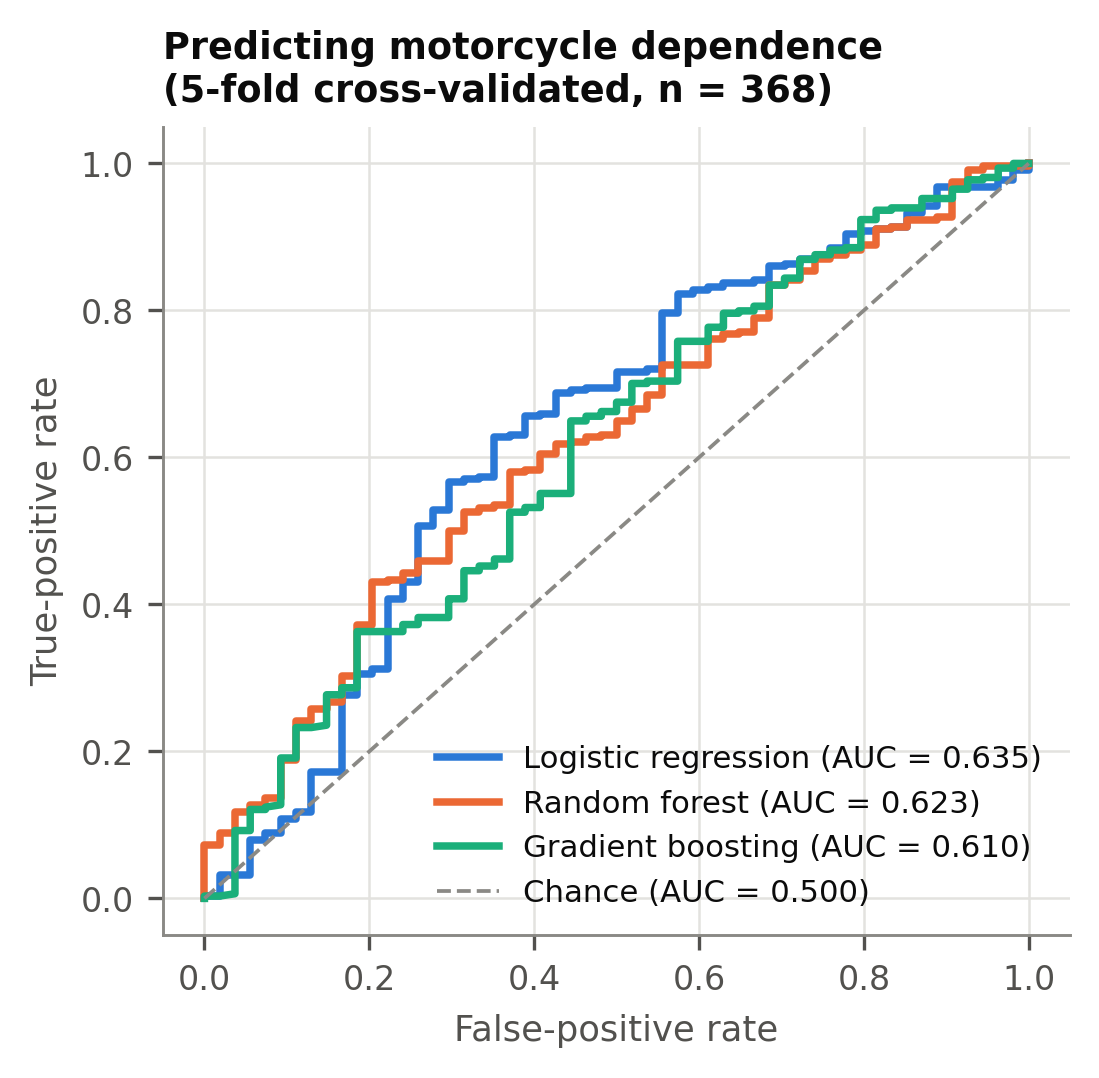

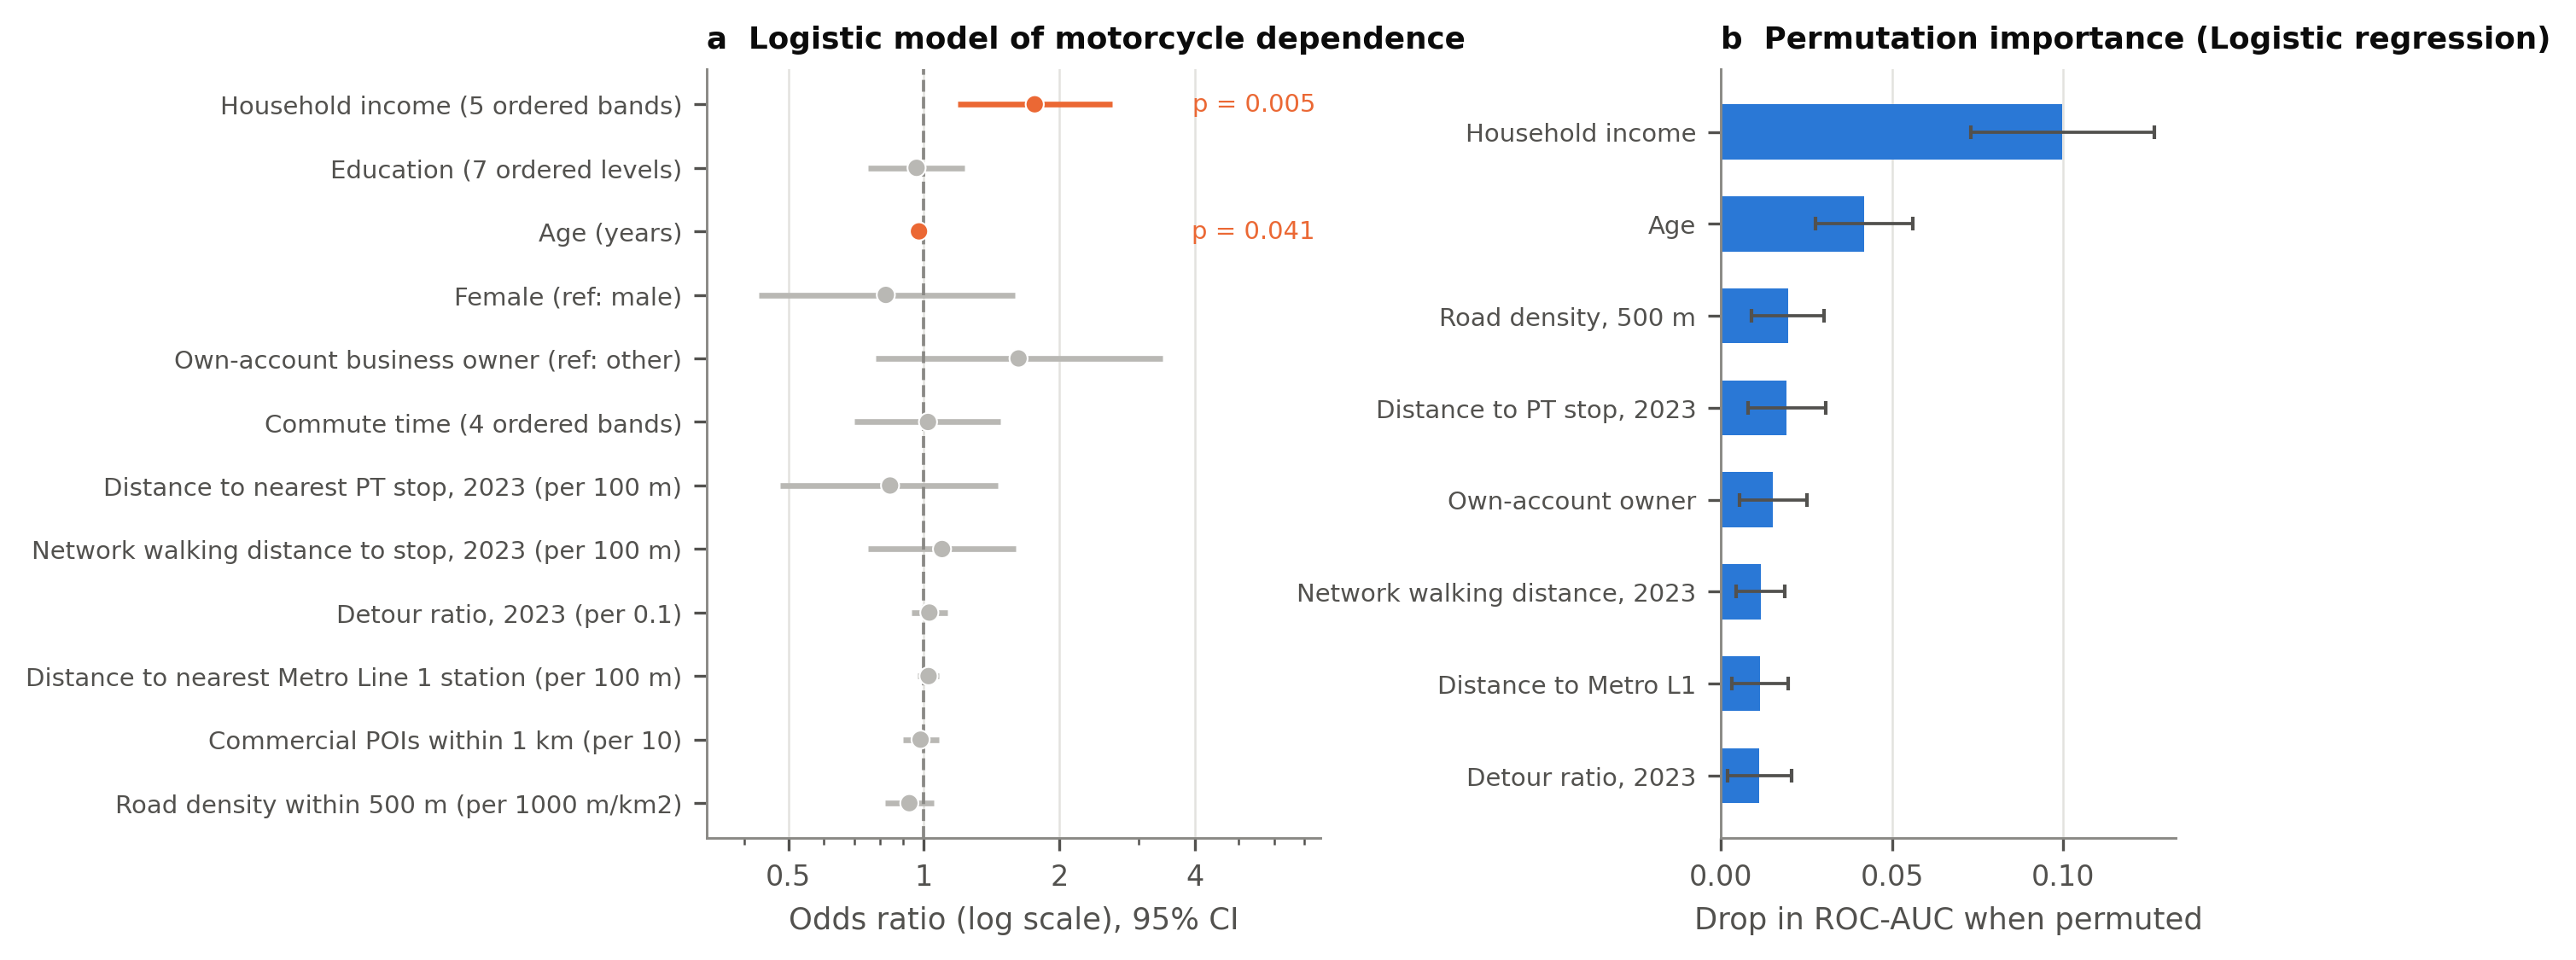

In [19]:
def f6():
    roc = json.load(open(DERIV / "roc.json", encoding="utf-8"))
    fig, ax = plt.subplots(figsize=(3.9, 3.5))
    for (nm, (fpr, tpr, auc)), c in zip(roc.items(), [S1, S2, S3]):
        ax.plot(fpr, tpr, color=c, lw=1.8, label=f"{nm} (AUC = {auc:.3f})")
    ax.plot([0, 1], [0, 1], color=MUT, lw=.9, ls="--", label="Chance (AUC = 0.500)")
    ax.set_xlabel("False-positive rate"); ax.set_ylabel("True-positive rate")
    ax.set_title("Predicting motorcycle dependence\n(5-fold cross-validated, n = %d)" % R["logit_n"],
                 loc="left", fontsize=8.8)
    ax.legend(loc="lower right", fontsize=7.4)
    tidy(ax, xgrid=True, ygrid=True)
    save(fig, "Figure6_roc")

# ================================================================ F7 OR + importance
def f7():
    t9 = pd.read_csv(TAB / "T9_logistic_motorcycle.csv")
    t9 = t9[t9.Predictor != "const"].copy()
    t9["lo"] = [float(s.strip("[]").split(",")[0]) for s in t9["95% CI"]]
    t9["hi"] = [float(s.strip("[]").split(",")[1]) for s in t9["95% CI"]]
    t9["pv"] = t9.p.astype(float)
    t9 = t9.iloc[::-1]
    t11 = pd.read_csv(TAB / "T11_permutation_importance.csv").head(8).iloc[::-1]

    SHORT = {"Household income (5 ordered bands)": "Household income",
             "Education (7 ordered levels)": "Education", "Age (years)": "Age",
             "Female (ref: male)": "Female", "Own-account business owner (ref: other)": "Own-account owner",
             "Commute time (4 ordered bands)": "Commute time",
             "Distance to nearest PT stop, 2023 (per 100 m)": "Distance to PT stop, 2023",
             "Network walking distance to stop, 2023 (per 100 m)": "Network walking distance, 2023",
             "Detour ratio, 2023 (per 0.1)": "Detour ratio, 2023",
             "Distance to nearest Metro Line 1 station (per 100 m)": "Distance to Metro L1",
             "Commercial POIs within 1 km (per 10)": "Commercial POIs, 1 km",
             "Road density within 500 m (per 1000 m/km2)": "Road density, 500 m"}
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.4, 3.9),
                                  gridspec_kw={"width_ratios": [1.35, 1]})
    fig.subplots_adjust(wspace=.75)
    y = np.arange(len(t9))
    col = [S2 if p < .05 else "#b9b8b4" for p in t9.pv]
    ax.hlines(y, t9.lo, t9.hi, color=col, lw=1.6)
    ax.scatter(t9.OR, y, s=26, c=col, zorder=3, lw=.5, edgecolor="white")
    ax.axvline(1, color=MUT, lw=.9, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(t9.Predictor, fontsize=7)
    ax.set_xscale("log"); ax.set_xlim(.33, 7.6)
    ax.set_xticks([.5, 1, 2, 4]); ax.set_xticklabels(["0.5", "1", "2", "4"])
    ax.set_xlabel("Odds ratio (log scale), 95% CI")
    ax.set_title("a  Logistic model of motorcycle dependence", loc="left", fontsize=8.6)
    for yy, (o, p) in enumerate(zip(t9.OR, t9.pv)):
        if p < .05:
            ax.text(7.4, yy, f"p = {p:.3f}", fontsize=7, color=S2, va="center", ha="right")
    tidy(ax, xgrid=True, ygrid=False)

    y2 = np.arange(len(t11))
    ax2.barh(y2, t11["Mean AUC drop"], color=S1, height=.6)
    ax2.errorbar(t11["Mean AUC drop"], y2, xerr=t11.SD, fmt="none",
                 ecolor=INK2, elinewidth=.9, capsize=2)
    ax2.set_yticks(y2)
    ax2.set_yticklabels([SHORT.get(p, p) for p in t11.Predictor], fontsize=7)
    ax2.set_xlabel("Drop in ROC-AUC when permuted")
    ax2.set_title(f"b  Permutation importance ({R['best_model']})", loc="left", fontsize=8.6)
    tidy(ax2, xgrid=True, ygrid=False)
    save(fig, "Figure7_model_effects")


f6(); f7()
for n in ['Figure6_roc','Figure7_model_effects']:
    display(Image(str(FIG/(n+'.png'))))

## 11 · Micro-enterprises — Tables 12–14, Figure 9

With *n* = 80 the analysis stays descriptive and non-parametric, as the outline requires. The
clustering is exploratory: the silhouette scores are reported so the reader can see how weak
the structure is.

In [20]:
# ============================================================ SMEs
SEC = {"Tạp hoá": "Grocery", "Kinh doanh dịch vụ ăn uống": "Food & drink service",
       "Buôn bán": "General trading", "Chế biến thực phẩm": "Food processing"}
sme["sector_en"] = sme["Q1.7_LVKD"].map(lambda v: SEC.get(v, "Other"))
sme["b2c"] = (sme["Q4.3_DTKH"] == "Người tiêu dùng (mô hình B2C)").astype(int)
sme["micro"] = (sme["Q1.8_SLNV"] == "0-5 người").astype(int)
TEN = {"<6 tháng": 0.5, "<1 năm": 1, "<2 năm": 2, "<5 năm": 5, ">5 năm": 8}
sme["tenure_y"] = sme["Q1.9_TGHD"].map(TEN)
CUS = {"<100": 50, ">100": 150, ">200": 250, ">300": 350, ">400": 450}
sme["customers_m"] = sme["Q4.4_SLKH"].map(CUS)
GRW = {"Đạt kết quả kém": 1, "Đạt kết quả khá tốt": 2, "Đạt kết quả tốt": 3, "Đạt kết quả xuất sắc": 4}
sme["growth"] = sme["Q4.1_TocDo_TT"].map(GRW)
for c in ["Q4.7_MucDo_LoiThe", "Q4.8_MucDo_TiepTuc", "Q4.9_MucDo_ThayDoiTot",
          "Q4.10_MucDo_CTHT", "Q4.11_MucDo_HTTP"]:
    sme[c] = pd.to_numeric(sme[c], errors="coerce")
sme["exposure"] = pd.cut(sme.d_metro_m_osm2026, [0, 500, 1000, 1e9],
                         labels=["<500 m", "500–1000 m", ">1000 m"])

t12 = pd.DataFrame({
    "Characteristic": ["Micro (0–5 staff)", "Grocery", "Food & drink service", "B2C only",
                       "<100 customers/month", "Trading <2 years", "Self-rated growth 'fair' or better"],
    "n": [int(sme.micro.sum()), int((sme.sector_en == "Grocery").sum()),
          int((sme.sector_en == "Food & drink service").sum()), int(sme.b2c.sum()),
          int((sme.customers_m == 50).sum()), int((sme.tenure_y <= 2).sum()),
          int((sme.growth >= 2).sum())]})
t12["% of 80"] = (100*t12.n/80).round(1)
T("T12_sme_profile", t12)
R["sme_micro"] = int(sme.micro.sum()); R["sme_b2c"] = int(sme.b2c.sum())
R["sme_med_dmetro"] = round(float(sme.d_metro_m_osm2026.median()), 0)
R["sme_exposure"] = sme.exposure.value_counts().to_dict()

PERC = {"Q4.7_MucDo_LoiThe": "Q4.7 My business has a competitive advantage here",
        "Q4.8_MucDo_TiepTuc": "Q4.8 I intend to keep trading at this location",
        "Q4.9_MucDo_ThayDoiTot": "Q4.9 Changes in this area are positive",
        "Q4.10_MucDo_CTHT": "Q4.10 SME support policy is effective",
        "Q4.11_MucDo_HTTP": "Q4.11 Legal/administrative support is adequate"}
rows = []
for c, lab in PERC.items():
    r = {"Item": lab, "M": round(float(sme[c].mean()), 2), "SD": round(float(sme[c].std()), 2)}
    samples = [sme.loc[sme.exposure == k, c].dropna().values for k in ["<500 m", "500–1000 m", ">1000 m"]]
    for k, s in zip(["<500 m", "500–1000 m", ">1000 m"], samples):
        r[f"M {k} (n={len(s)})"] = round(float(np.mean(s)), 2) if len(s) else np.nan
    ok = [s for s in samples if len(s) > 2]
    if len(ok) > 1:
        H, p = stats.kruskal(*ok); r["H"] = round(H, 2); r["p"] = f"{p:.3f}"
    rows.append(r)
t13 = T("T13_sme_perceptions_by_exposure", pd.DataFrame(rows))
R["sme_perc"] = {r["Item"]: (r["M"], r["SD"], r.get("p")) for r in rows}

# ---- T14 SME vulnerability clusters
cl_feat = ["micro", "b2c", "tenure_y", "customers_m", "growth", "d_metro_m_osm2026",
           "poi_1000m_osm2026", "Q4.7_MucDo_LoiThe", "Q4.8_MucDo_TiepTuc"]
C = sme[cl_feat].apply(pd.to_numeric, errors="coerce")
C = C.fillna(C.median())
Z = StandardScaler().fit_transform(C)
sil = {}
from sklearn.metrics import silhouette_score
for k in range(2, 6):
    lab = KMeans(k, n_init=50, random_state=42).fit_predict(Z)
    sil[k] = round(float(silhouette_score(Z, lab)), 3)
kbest = max(sil, key=sil.get)
sme["cluster"] = KMeans(kbest, n_init=50, random_state=42).fit_predict(Z)
prof = sme.groupby("cluster")[cl_feat].median().round(2)
prof["n"] = sme.cluster.value_counts().sort_index()
T("T14_sme_clusters", prof.reset_index())
R["sme_k"] = int(kbest); R["sme_sil"] = sil
R["sme_cluster_n"] = sme.cluster.value_counts().sort_index().to_dict()


display(t13, prof)

,Item,M,SD,M <500 m (n=12),M 500–1000 m (n=18),M >1000 m (n=50),H,p
0,Q4.7 My business has a competitive advantage here,3.04,0.77,3.08,2.94,3.06,0.72,0.698
1,Q4.8 I intend to keep trading at this location,3.69,0.67,3.67,3.83,3.64,1.21,0.545
2,Q4.9 Changes in this area are positive,3.71,0.56,3.67,3.67,3.74,0.39,0.824
3,Q4.10 SME support policy is effective,3.29,0.87,3.58,3.61,3.10,6.60,0.037
4,Q4.11 Legal/administrative support is adequate,3.05,0.69,3.08,3.06,3.04,0.09,0.956


,micro,b2c,tenure_y,customers_m,growth,d_metro_m_osm2026,poi_1000m_osm2026,Q4.7_MucDo_LoiThe,Q4.8_MucDo_TiepTuc,n
cluster,,,,,,,,,,
0,1.0,1.0,5.0,50.0,2.0,1331.22,85.5,3.0,4.0,50
1,1.0,1.0,5.0,250.0,2.0,465.94,162.0,3.0,4.0,15
2,0.0,1.0,5.0,150.0,2.0,874.26,78.0,3.0,4.0,5
3,1.0,0.0,2.0,50.0,2.0,1125.74,56.0,3.0,3.5,10


   Figure9_sme_exposure


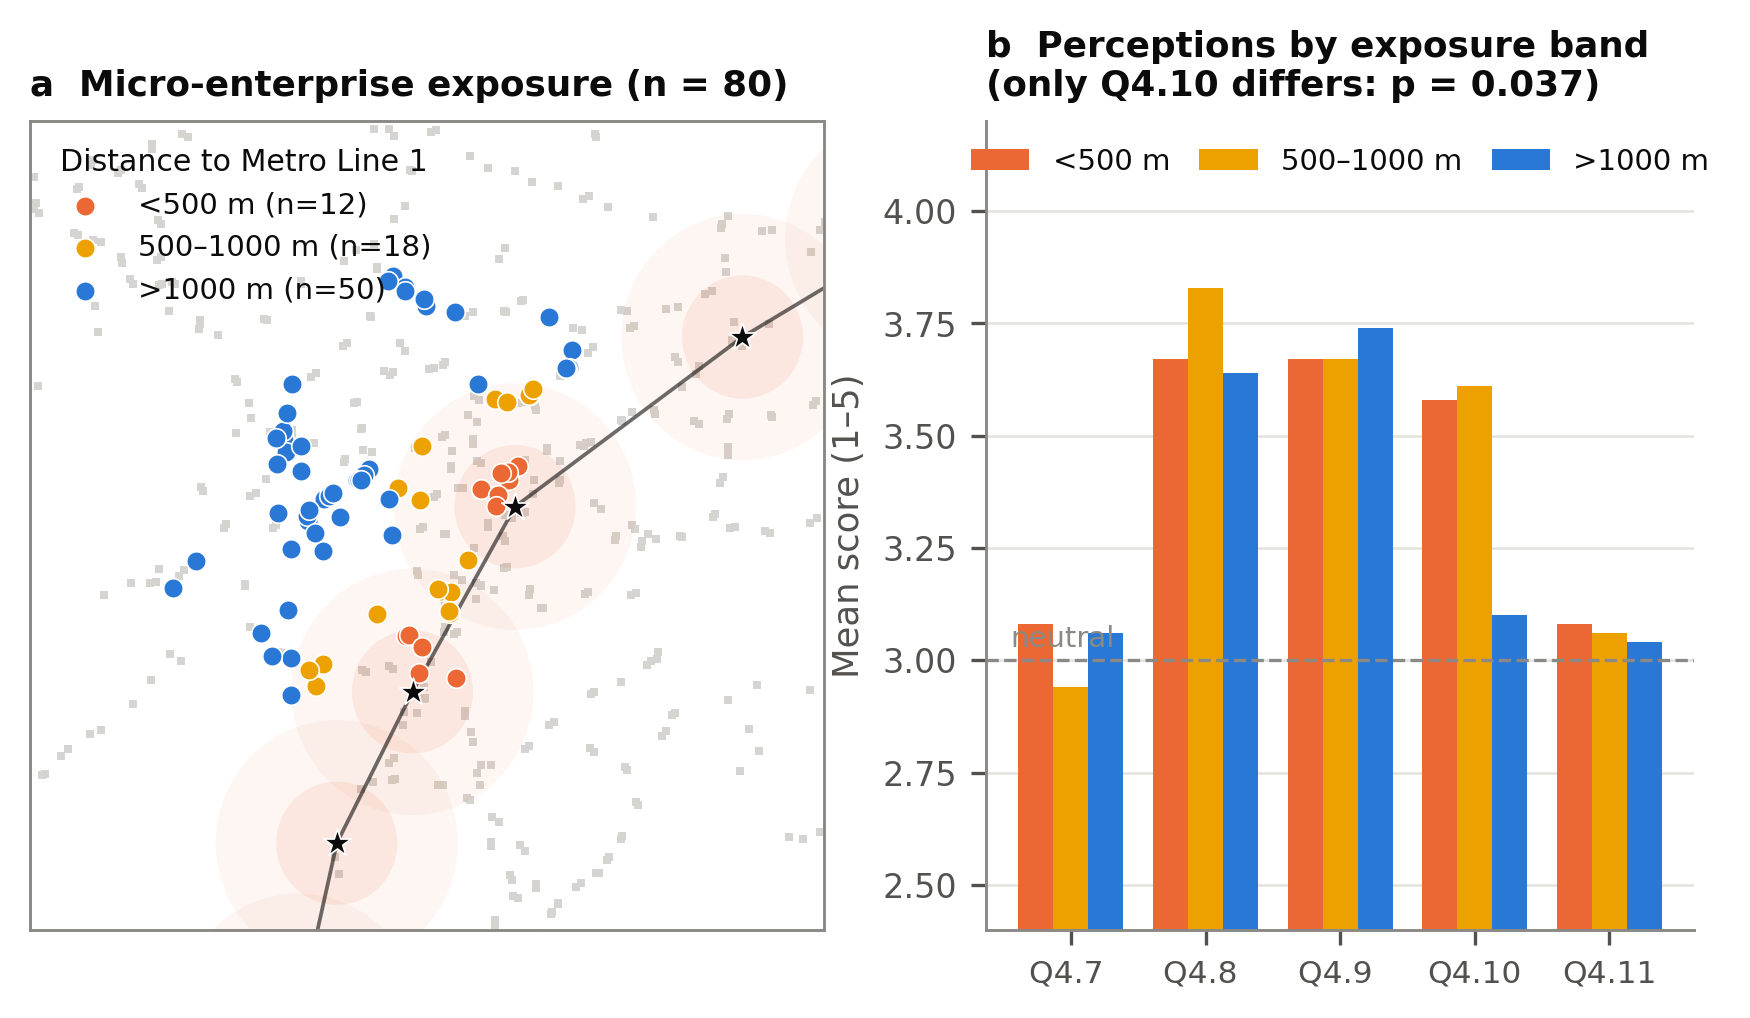

In [21]:
def f9():
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.5),
                                  gridspec_kw={"width_ratios": [1.15, 1]})
    ax.scatter(b26.lon, b26.lat, s=3, c="#d5d4d0", marker="s", lw=0)
    for r in m26.itertuples():
        for rad, a in [(500, .10), (1000, .06)]:
            ax.add_patch(Circle((r.lon, r.lat), rad/(111320*np.cos(np.radians(10.82))),
                                fc=S2, ec="none", alpha=a, zorder=1))
    cmap = {"<500 m": S2, "500–1000 m": S4, ">1000 m": S1}
    for k, c in cmap.items():
        d = sme[sme.exposure == k]
        ax.scatter(d.Long, d.Lat, s=22, c=c, lw=.4, edgecolor="white", zorder=3,
                   label=f"{k} (n={len(d)})")
    ax.scatter(m26.lon, m26.lat, s=48, marker="*", c=INK, lw=.4, edgecolor="white", zorder=4)
    ax.plot(m26.lon, m26.lat, c=INK, lw=.9, alpha=.6, zorder=2)
    ax.set_xlim(106.735, 106.795); ax.set_ylim(10.815, 10.875)
    ax.set_aspect(1/np.cos(np.radians(10.82)))
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True); s.set_color(MUT)
    ax.legend(loc="upper left", fontsize=7, title="Distance to Metro Line 1",
              title_fontsize=7.2)
    ax.set_title(f"a  Micro-enterprise exposure (n = {len(sme)})", loc="left", fontsize=8.6)

    t13 = pd.read_csv(TAB / "T13_sme_perceptions_by_exposure.csv")
    items = t13.Item.str[:5].values
    bands = ["<500 m", "500–1000 m", ">1000 m"]
    cols = [t13[c] for c in t13.columns if c.startswith("M <500") or c.startswith("M 500") or c.startswith("M >1000")]
    x = np.arange(len(items)); w = .26
    for j, (b, c) in enumerate(zip(bands, [S2, S4, S1])):
        ax2.bar(x+(j-1)*w, cols[j], width=w, color=c, label=b)
    ax2.axhline(3, color=MUT, lw=.8, ls="--")
    ax2.text(-.45, 3.03, "neutral", fontsize=7, color=MUT, ha="left")
    ax2.set_xticks(x); ax2.set_xticklabels(items, fontsize=7.5)
    ax2.set_ylim(2.4, 4.2); ax2.set_ylabel("Mean score (1–5)")
    ax2.legend(fontsize=7, ncol=3, loc="upper center", columnspacing=1)
    ax2.set_title("b  Perceptions by exposure band\n(only Q4.10 differs: p = %s)"
                  % R["sme_perc"]["Q4.10 SME support policy is effective"][2],
                  loc="left", fontsize=8.6)
    tidy(ax2)
    save(fig, "Figure9_sme_exposure")


f9()
display(Image(str(FIG/'Figure9_sme_exposure.png')))

## 12 · The diagnostic gap and the institutional benchmark — Tables 15–16, Figures 8 and 11

Residents and officials answered the *same* question about why residents do not use public
transport. The comparison is the sharpest instrument in the paper, and the PCI series supplies
an external benchmark that keeps the *n* = 80 enterprise sample honest.

In [22]:
# ============================================================ T15 policy gap
AUT28 = {"Tốn thời gian khi di chuyển": ("Travel takes too long", "Service / system"),
         "Văn hóa đi xe bus chưa tốt": ("Weak bus-riding culture", "Behavioural"),
         "Đi bộ không thoải mái từ/đến các trạm": ("Walking to stops is uncomfortable", "Experiential"),
         "Tần suất các chuyến chưa đủ": ("Service frequency insufficient", "Infrastructure"),
         "Không ý kiến": ("No opinion", "No opinion")}
aut["reason_en"] = aut["Q2.8"].map(lambda v: AUT28.get(v, ("Other", "Other"))[0])
aut["reason_class"] = aut["Q2.8"].map(lambda v: AUT28.get(v, ("Other", "Other"))[1])
cc = cit[cit.reason_class != "Not a barrier"].reason_class.value_counts()
ac = aut[aut.reason_class != "No opinion"].reason_class.value_counts()
classes = ["Behavioural", "Experiential", "Infrastructure", "Service / system", "Service"]
rows = []
for k in ["Behavioural", "Experiential", "Infrastructure", "Service"]:
    ck = int(cc.get(k, 0))
    ak = int(ac.get(k, 0) + (ac.get("Service / system", 0) if k == "Service" else 0))
    rows.append({"Barrier class": k,
                 "Residents n": ck, "Residents %": round(100*ck/cc.sum(), 1),
                 "Officials n": ak, "Officials %": round(100*ak/ac.sum(), 1),
                 "Gap (pp)": round(100*ck/cc.sum() - 100*ak/ac.sum(), 1)})
t15 = pd.DataFrame(rows)
tab = np.array([[r["Residents n"] for r in rows], [r["Officials n"] for r in rows]])
chi2, p, dof, exp = stats.chi2_contingency(tab)
try:
    _, pf = stats.fisher_exact(tab[:, [0, 2]])
except Exception:
    pf = np.nan
T("T15_policy_gap", t15)
R["gap_chi2"] = round(chi2, 2); R["gap_p"] = f"{p:.4f}"; R["gap_dof"] = int(dof)
R["aut_top_reason"] = aut.reason_en.value_counts().index[0]
R["aut_top_n"] = int(aut.reason_en.value_counts().iloc[0])
R["aut_behav_n"] = int(ac.get("Behavioural", 0)); R["aut_n_answered"] = int(ac.sum())
R["aut_noop"] = int((aut.reason_class == "No opinion").sum())
T("T15b_auth_Q211", aut["Q2.11"].value_counts().rename_axis("Q2.11 SME support policy").reset_index(name="n"))
R["aut_q211"] = aut["Q2.11"].value_counts().to_dict()

# ============================================================ T16 PCI benchmark
PCI = {2021: "_data_pci_file_general_file_1651635859-Indicator_PCI2021_EN.xlsx",
       2022: "_data_pci_file_general_file_1681152490-Appendix_1_Table_Indicator_PCI2022_EN_web.xlsx",
       2023: "_data_pci_file_general_file_1715183901-Appendix_1_Table_Indicator_PCI2023_EN_web.xlsx",
       2024: "_data_pci_file_general_file_1746601947-Appendix_1_Table_Indicator_PCI_2024_EN_web.xlsx"}
rows = []
for yr, f in PCI.items():
    d = pd.read_excel(DSET / "PCI DATA 2006-2024" / f, sheet_name=0, header=0)
    d.columns = [str(c).strip() for c in d.columns]
    prov = d.columns[0]
    bss = [c for c in d.columns if "Business Support" in c or "BSS" in c]
    if not bss:
        continue
    b = pd.to_numeric(d[bss[0]], errors="coerce")
    hcm = d[d[prov].astype(str).str.contains("HCMC|Ho Chi Minh", case=False, na=False)]
    if not len(hcm):
        continue
    v = float(pd.to_numeric(hcm[bss[0]], errors="coerce").iloc[0])
    rows.append({"Year": yr, "Sub-index": "Business Support Policy",
                 "HCMC score": round(v, 2), "National median": round(float(b.median()), 2),
                 "National mean": round(float(b.mean()), 2),
                 "HCMC rank (of provinces scored)": int((b > v).sum()+1),
                 "Provinces scored": int(b.notna().sum())})
d25 = pd.read_excel(DSET / "Du lieu PCI 2025.xlsx", sheet_name=0, header=0)
d25.columns = [str(c).strip() for c in d25.columns]
c7 = [c for c in d25.columns if "Hỗ trợ doanh nghiệp" in c]
if c7:
    b = pd.to_numeric(d25[c7[0]], errors="coerce")
    hcm = d25[d25.iloc[:, 0].astype(str).str.contains("Hồ Chí Minh", na=False)]
    if len(hcm):
        v = float(pd.to_numeric(hcm[c7[0]], errors="coerce").iloc[0])
        rows.append({"Year": 2025, "Sub-index": "Business & labour support (new 9-index frame)",
                     "HCMC score": round(v, 2), "National median": round(float(b.median()), 2),
                     "National mean": round(float(b.mean()), 2),
                     "HCMC rank (of provinces scored)": int((b > v).sum()+1),
                     "Provinces scored": int(b.notna().sum())})
t16 = T("T16_pci_benchmark", pd.DataFrame(rows))
R["pci"] = rows


display(t15, t16)

,Barrier class,Residents n,Residents %,Officials n,Officials %,Gap (pp)
0,Behavioural,313,70.2,4,19.0,51.1
1,Experiential,71,15.9,3,14.3,1.6
2,Infrastructure,51,11.4,2,9.5,1.9
3,Service,11,2.5,12,57.1,-54.7


,Year,Sub-index,HCMC score,National median,National mean,HCMC rank (of provinces scored),Provinces scored
0,2021,Business Support Policy,8.54,6.85,7.54,2,68
1,2022,Business Support Policy,7.04,5.82,6.35,2,68
2,2023,Business Support Policy,7.37,6.45,6.39,8,67
3,2024,Business Support Policy,7.81,7.18,7.86,13,68
4,2025,Business & labour support (new 9-index frame),5.61,5.43,5.46,14,37


   Figure8_policy_gap
   Figure11_pci


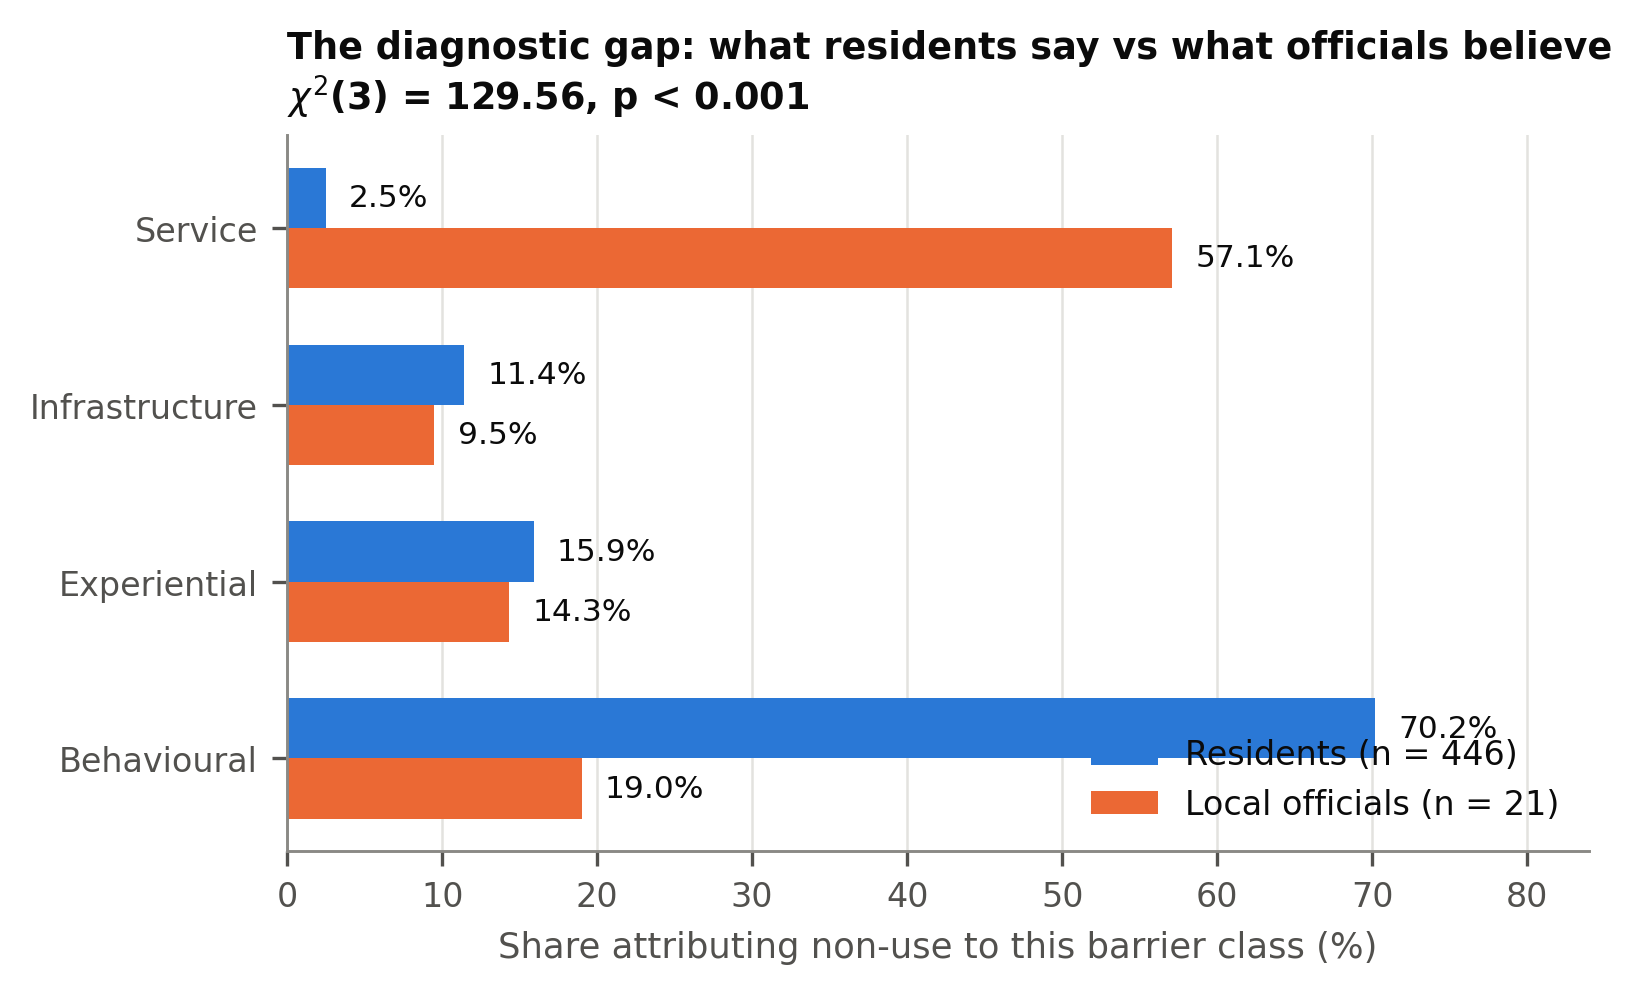

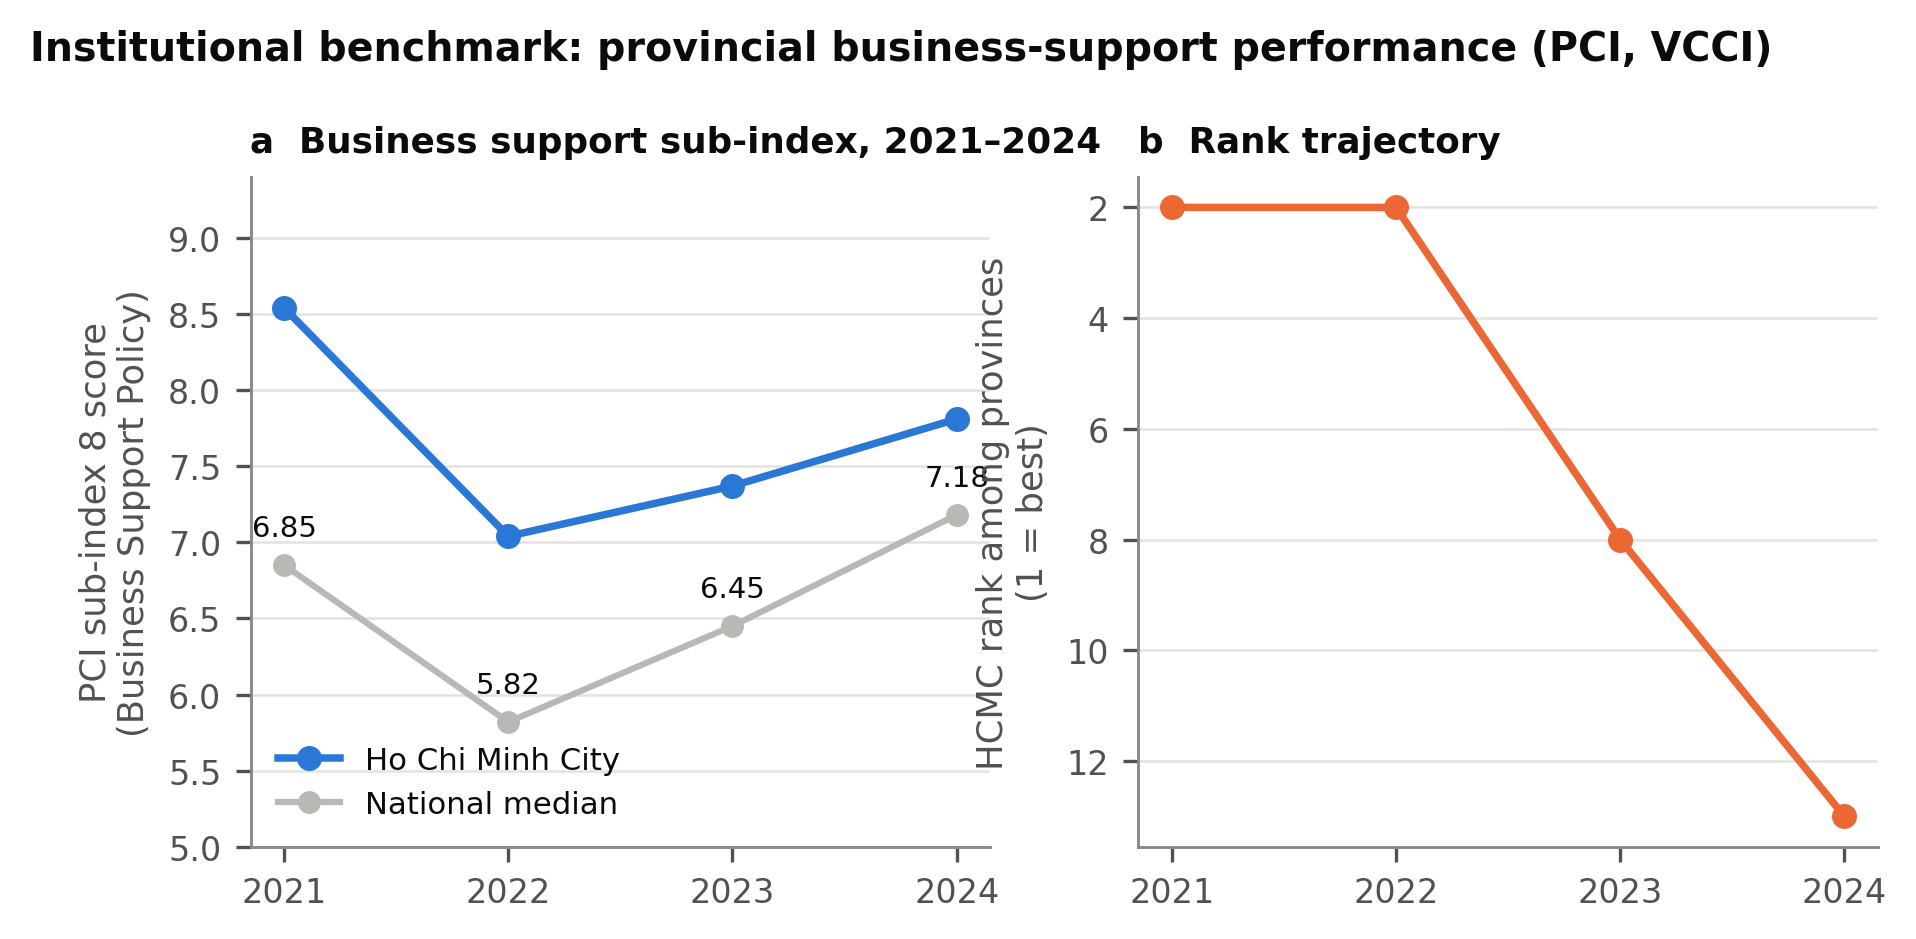

In [23]:
def f8():
    t15 = pd.read_csv(TAB / "T15_policy_gap.csv")
    fig, ax = plt.subplots(figsize=(5.6, 3.1))
    y = np.arange(len(t15))
    h = .34
    ax.barh(y+h/2, t15["Residents %"], height=h, color=S1,
            label=f"Residents (n = {R['n_citizens']-R['n_user']})")
    ax.barh(y-h/2, t15["Officials %"], height=h, color=S2,
            label=f"Local officials (n = {R['aut_n_answered']})")
    for i, r in t15.iterrows():
        ax.text(r["Residents %"]+1.5, i+h/2, f"{r['Residents %']:.1f}%", va="center", fontsize=7.5, color=INK)
        ax.text(r["Officials %"]+1.5, i-h/2, f"{r['Officials %']:.1f}%", va="center", fontsize=7.5, color=INK)
    ax.set_yticks(y); ax.set_yticklabels(t15["Barrier class"])
    ax.set_xlim(0, 84); ax.set_xlabel("Share attributing non-use to this barrier class (%)")
    ax.set_title("The diagnostic gap: what residents say vs what officials believe\n"
                 f"$\\chi^2$({R['gap_dof']}) = {R['gap_chi2']}, p < 0.001", loc="left", fontsize=8.8)
    ax.legend(loc="lower right")
    tidy(ax, xgrid=True, ygrid=False)
    save(fig, "Figure8_policy_gap")

def f11():
    t16 = pd.read_csv(TAB / "T16_pci_benchmark.csv")
    a = t16[t16.Year <= 2024]
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(7.0, 2.9))
    ax.plot(a.Year, a["HCMC score"], "-o", color=S1, lw=1.8, ms=5, label="Ho Chi Minh City")
    ax.plot(a.Year, a["National median"], "-o", color="#b9b8b4", lw=1.5, ms=4.5,
            label="National median")
    for r in a.itertuples():
        ax.annotate(f"{r._4:.2f}", (r.Year, r._4), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=7, color=INK)
    ax.set_xticks(a.Year); ax.set_ylim(5, 9.4)
    ax.set_ylabel("PCI sub-index 8 score\n(Business Support Policy)")
    ax.set_title("a  Business support sub-index, 2021–2024", loc="left", fontsize=8.6)
    ax.legend(loc="lower left", fontsize=7.4)
    tidy(ax)

    ax2.plot(a.Year, a["HCMC rank (of provinces scored)"], "-o", color=S2, lw=1.8, ms=5)
    for r in a.itertuples():
        ax2.annotate(f"#{int(r._7)}", (r.Year, r._7), textcoords="offset points",
                     xytext=(0, -13), ha="center", fontsize=7.5, color=INK)
    ax2.invert_yaxis(); ax2.set_xticks(a.Year)
    ax2.set_ylabel("HCMC rank among provinces\n(1 = best)")
    ax2.set_title("b  Rank trajectory", loc="left", fontsize=8.6)
    tidy(ax2)
    fig.suptitle("Institutional benchmark: provincial business-support performance (PCI, VCCI)",
                 fontsize=9.5, fontweight="bold", y=1.05, x=.02, ha="left")
    save(fig, "Figure11_pci")


f8(); f11()
for n in ['Figure8_policy_gap','Figure11_pci']:
    display(Image(str(FIG/(n+'.png'))))

## 13 · Built-environment change along the corridor — Tables 17–18, Figure 10

Three independent remote-sensing sources, read in rings around the fourteen stations. Note in
advance that GHS-POP 2025 is a **modelled projection, not an observation**: if its growth rate
is flat across every ring, that is a property of the model, not evidence about the corridor.

In [24]:
# ============================================================ T17 built environment by distance band
band = pd.cut(g.d_metro_m_osm2026, [0, 500, 1000, 1500, 1e9],
              labels=["<500 m", "500–1000 m", "1000–1500 m", ">1500 m"])
bt = g.groupby(band, observed=True).agg(
    n=("rid", "size"),
    pop_2020=("pop_dens_2020", "median"), pop_2025=("pop_dens_2025", "median"),
    built_2020=("built_s_2020", "median"), built_2025=("built_s_2025", "median"),
    ndbi_2023=("ndbi_2023", "median"), ndbi_2026=("ndbi_2026", "median"),
    d_ndbi=("d_ndbi", "median")).round(3).reset_index()
bt["pop growth %"] = (100*(bt.pop_2025-bt.pop_2020)/bt.pop_2020).round(1)
bt["built-up growth %"] = (100*(bt.built_2025-bt.built_2020)/bt.built_2020).round(1)
T("T17_built_environment_bands", bt)
kw_pop = stats.kruskal(*[g.loc[band == k, "pop_growth_pct"].dropna().values
                         for k in bt.iloc[:, 0]])
R["pop_growth_kw"] = {"H": round(kw_pop.statistic, 2), "p": f"{kw_pop.pvalue:.3f}"}
R["built_bands"] = bt.to_dict("records")


bt

,d_metro_m_osm2026,n,pop_2020,pop_2025,built_2020,built_2025,ndbi_2023,ndbi_2026,d_ndbi,pop growth %,built-up growth %
0,<500 m,46,167.915,190.629,4104.0,4104.0,0.036,0.047,0.011,13.5,0.0
1,500–1000 m,66,200.911,226.631,4517.5,4517.5,0.074,0.080,0.011,12.8,0.0
2,1000–1500 m,86,186.857,212.133,4682.0,4682.0,0.066,0.073,0.005,13.5,0.0
3,>1500 m,261,178.265,202.379,4655.0,4655.0,0.106,0.115,0.012,13.5,0.0


   Figure10_corridor_rings


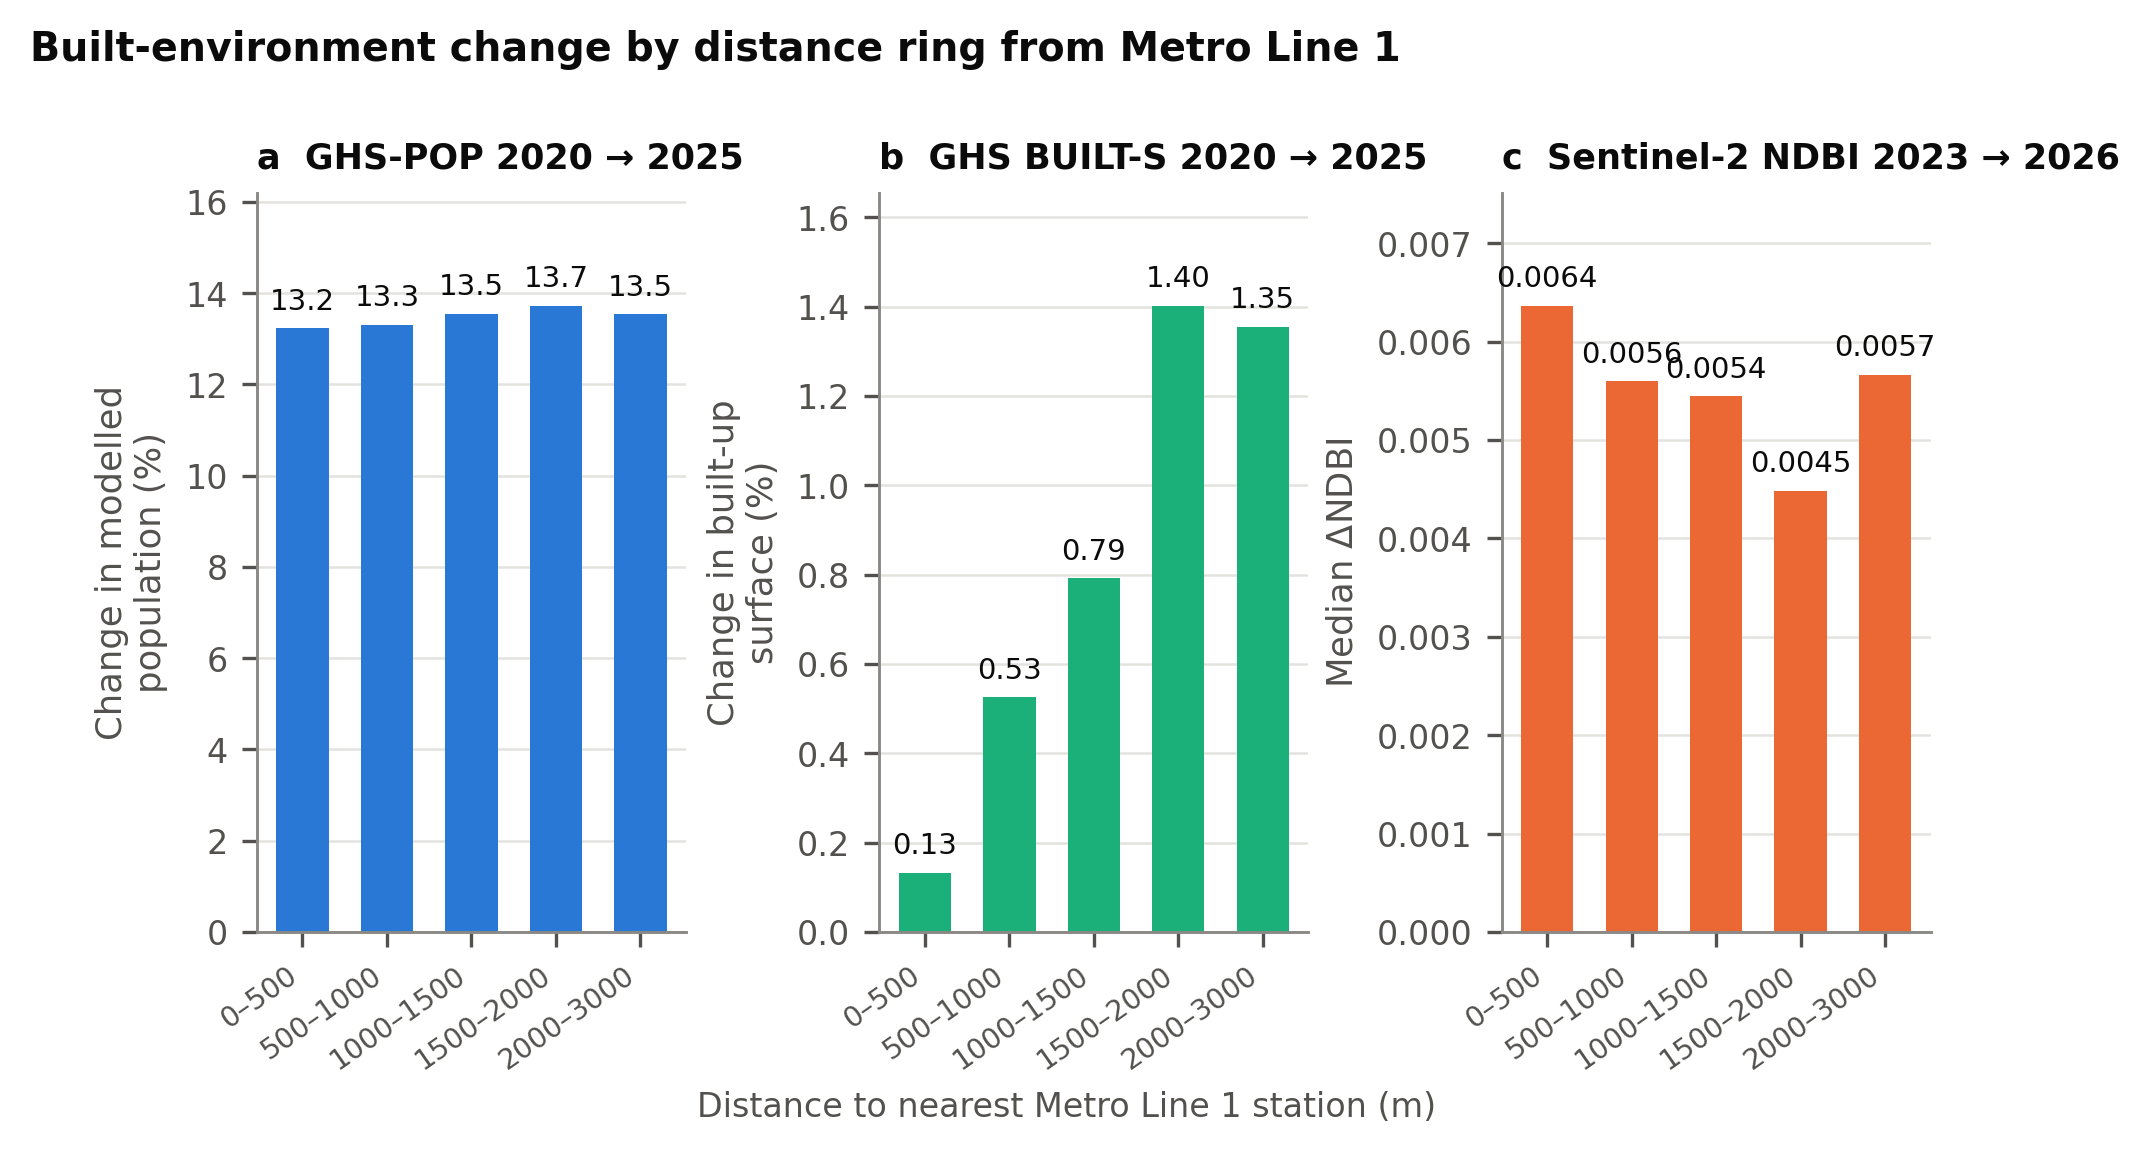

In [25]:
def f10():
    TR = Transformer.from_crs("EPSG:4326", "EPSG:32648", always_xy=True)
    sx, sy = TR.transform(m26.lon.values, m26.lat.values)
    layers = {}
    for nm, path in [("pop2020", CLIP / "GHSPOP_2020_TTLL.tif"),
                     ("pop2025", CLIP / "GHSPOP_2025_TTLL.tif"),
                     ("bs2020", CLIP / "GHSBUILTS_2020_TTLL.tif"),
                     ("bs2025", CLIP / "GHSBUILTS_2025_TTLL.tif")]:
        with rasterio.open(str(path)) as src:
            a = src.read(1).astype(float)
            rows, cols = np.indices(a.shape)
            X, Y = rasterio.transform.xy(src.transform, rows, cols)
            t2 = Transformer.from_crs(src.crs, "EPSG:32648", always_xy=True)
            ux, uy = t2.transform(np.ravel(X), np.ravel(Y))
            layers[nm] = (a.ravel(), np.asarray(ux), np.asarray(uy))
    a, ux, uy = layers["pop2020"]
    d = np.min(np.stack([np.hypot(ux-x, uy-y) for x, y in zip(sx, sy)]), axis=0)
    edges = [0, 500, 1000, 1500, 2000, 3000]
    lab = ["0–500", "500–1000", "1000–1500", "1500–2000", "2000–3000"]
    pop_g, bs_g, pop_abs = [], [], []
    for i in range(len(edges)-1):
        m = (d >= edges[i]) & (d < edges[i+1])
        p0, p1 = layers["pop2020"][0][m].sum(), layers["pop2025"][0][m].sum()
        b0, b1 = layers["bs2020"][0][m].sum(), layers["bs2025"][0][m].sum()
        pop_g.append(100*(p1-p0)/p0); bs_g.append(100*(b1-b0)/b0); pop_abs.append(p0)

    ndbi_g = []
    with rasterio.open(str(DATA / "Delta_NDBI_2023_2026_HCMC.tif")) as src:
        an = src.read(1).astype(float).ravel()
        an[~np.isfinite(an)] = np.nan
        rr, cc = np.indices(src.shape)
        X, Y = rasterio.transform.xy(src.transform, rr, cc)
        t2 = Transformer.from_crs(src.crs, "EPSG:32648", always_xy=True)
        nx_, ny_ = t2.transform(np.ravel(X), np.ravel(Y))
        nx_, ny_ = np.asarray(nx_), np.asarray(ny_)
        dn = np.min(np.stack([np.hypot(nx_-x, ny_-y) for x, y in zip(sx, sy)]), axis=0)
        for i in range(len(edges)-1):
            m = (dn >= edges[i]) & (dn < edges[i+1]) & np.isfinite(an)
            ndbi_g.append(np.nanmedian(an[m]) if m.sum() else np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.2))
    fig.subplots_adjust(wspace=.45)
    for ax, vals, ttl, ylab, c in [
            (axes[0], pop_g, "a  GHS-POP 2020 → 2025", "Change in modelled\npopulation (%)", S1),
            (axes[1], bs_g, "b  GHS BUILT-S 2020 → 2025", "Change in built-up\nsurface (%)", S3),
            (axes[2], ndbi_g, "c  Sentinel-2 NDBI 2023 → 2026", "Median $\\Delta$NDBI", S2)]:
        vals = np.asarray(vals, float)
        ax.bar(np.arange(len(lab)), vals, color=c, width=.62)
        mx = np.nanmax(np.abs(vals))
        fmt = "{:.4f}" if mx < .05 else ("{:.2f}" if mx < 5 else "{:.1f}")
        for i, v in enumerate(vals):
            ax.text(i, v + .03*mx, fmt.format(v), ha="center", fontsize=7, color=INK)
        ax.set_ylim(0, mx*1.18)
        ax.set_xticks(np.arange(len(lab)))
        ax.set_xticklabels(lab, fontsize=6.8, rotation=35, ha="right")
        ax.set_ylabel(ylab); ax.set_title(ttl, loc="left", fontsize=8.4)
        tidy(ax)
    fig.supxlabel("Distance to nearest Metro Line 1 station (m)", fontsize=8, y=-.09,
                  color=INK2)
    fig.suptitle("Built-environment change by distance ring from Metro Line 1",
                 fontsize=9.5, fontweight="bold", y=1.05, x=.02, ha="left")
    save(fig, "Figure10_corridor_rings")
    pd.DataFrame({"ring_m": lab, "pop_change_pct": np.round(pop_g, 2),
                  "builts_change_pct": np.round(bs_g, 3),
                  "median_dNDBI": np.round(ndbi_g, 4),
                  "pop_2020_in_ring": np.round(pop_abs, 0)}).to_csv(
        TAB / "T18_corridor_rings.csv", index=False)


f10()
display(Image(str(FIG/'Figure10_corridor_rings.png')))

## 14 · Export every headline number

`results.json` is the single source of truth for the manuscript: every figure quoted in the text is read from it, so the prose cannot drift away from the analysis.

In [27]:
cit.to_csv(DERIV / "citizens_analysis.csv", index=False)
sme.to_csv(DERIV / "smes_analysis.csv",     index=False)
with open(DERIV / "results.json", "w", encoding="utf-8") as f:
    json.dump(R, f, indent=1, default=str, ensure_ascii=False)
print("figures :", len(list(FIG.glob("*.png"))))
print("tables  :", len(list(TAB.glob("*.csv"))))
print("results :", DERIV / "results.json")
print()
for k in ["pct_behav", "pct_infra", "ratio_behav_infra", "ratio_wide", "n_metro_2023",
          "bus_growth_pct", "med_dbus23", "med_dbus26", "logit_income_or", "logit_income_p",
          "best_model", "gap_chi2", "aut_top_reason"]:
    print(f"  {k:22s} {R[k]}")

figures : 12
tables  : 19
results : D:\Support\Paper2026\17_TruongTho\Paper3\Derived\results.json

  pct_behav              68.0
  pct_infra              11.1
  ratio_behav_infra      6.1
  ratio_wide             7.5
  n_metro_2023           14
  bus_growth_pct         160.0
  med_dbus23             290.0
  med_dbus26             140.0
  logit_income_or        1.76
  logit_income_p         0.005
  best_model             Logistic regression
  gap_chi2               129.56
  aut_top_reason         Travel takes too long
